# Cross-BA Stress Correlation — Pillar 2 Notebook (v5)
## Destination-Specific Coincidence Factors for Spatial Migration

**Fundamental Research Question:** When ComEd experiences grid stress, what fraction of cross-BA destination capacity is *also* stressed — and is the residual uncorrelated capacity large enough, deep enough, and reliable enough to underwrite spatial migration as a PJM capacity resource?

**Role in the three-pillar thesis:** This notebook produces the empirical destination parameters (cross-BA availability, price conditions during source stress, cascade-compatible destination set) that feed Pillar 1's seven-parameter cascade and Pillar 3's capacity market integration. The JSON export in Part 6 is the interface to `bartlett_analysis_v15.ipynb`.

**Inputs:** Parquet files from `price_data_preprocessing.ipynb` (35,060 hours of DA LMP data, 19 hourly + 2 daily destination zones, Jan 2022 – Dec 2025).
**Outputs:** `stress_correlation_results.json` — empirical parameters consumed by the governing Bartlett notebook.

---

### Notebook Architecture

| Part | Section | What It Establishes |
|------|---------|---------------------|
| **0** | **Setup and Data** | Config, parquet load, price-based stress hour identification |
| **1** | **Headline Result** | Intra-PJM control → cross-BA overlap → capacity-weighted coincidence factor |
| **2** | **Robustness** | Seasonal, year-by-year, destination LMPs, price correlation, named events |
| **3** | **Extensions** | WECC daily hubs, multi-source zone generalizability |
| **4** | **Conditional Monte Carlo** | Joint D1–D5 feasibility under risk profile, single facility and fleet |
| **5** | **Sensitivity** | Scenario vs cascade comparison, 2D surface, tornado |
| **6** | **Export and Paper Summary** | JSON contract, consolidated paper tables |

### Methodological Changes from v3 (preserved from v4)

1. **Cross-BA framing** — any BA with independent RA planning is a valid destination, not just cross-Interconnect.
2. **Price-only stress identification** — nodal LMPs capture both demand- and supply-driven stress; demand data is not available at destination granularity.
3. **ComEd-specific source** — not PJM system-wide demand.
4. **19 hourly + 2 daily destination zones** — versus 3 RTO-wide comparators in v3.
5. **Intra-PJM control group** — same-RTO zones should be correlated during stress; the control establishes that baseline before cross-BA decorrelation is measured against it.
6. **Capacity-weighted coincidence factor** — weights destination overlap by actual DC MW siting.

### Key Parameters

| Parameter | Value | Source |
|-----------|-------|--------|
| Source zone | PJM_COMED | — |
| Stress threshold | Top-N% DA LMP hours | Cell 0-3 |
| Data window | Jan 2022 – Dec 2025 | 35,060 hours |
| Hourly destinations | 19 zones | meta |
| Daily destinations | 2 hubs (Mid-C, Palo Verde) | meta |
| MC draws / stress hour | 2,000 | Part 4 |

### Headline Results

| Metric | Value | Part |
|--------|-------|------|
| Capacity-weighted cross-BA availability during ComEd stress | ~94.5% | 1.3 |
| Effective spatial fraction (central) | ~0.390 | 4.3 |
| Conditional commitment depth (inference-dominant) | ~54% | 4.3 |
| Cascade commitment reference | 21.0% | 4 |

*(Numbers are placeholders — verify against your regression set and overwrite after the first clean run.)*

## Part 0: Setup and Data

- **0.1** Configuration and imports
- **0.2** Load preprocessed parquet data
- **0.3** Stress hour identification (price-based)

Establishes the source dataset and the stress-hour definition that every downstream Part depends on. The design choice to define stress on nodal DA LMPs rather than loads is not cosmetic: destination-granularity demand data does not exist, and LMPs are the only signal that captures both demand- and supply-driven tightness at every node in the study. Stress hours identified here are the filter applied throughout Parts 1–5.

### 0.1 Configuration and Imports

Paths, constants, and the full import block. `scipy` is installed here rather than inside Part 4 so the environment is fully resolved before any analysis runs.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-1: CONFIGURATION AND IMPORTS (v5)
# ══════════════════════════════════════════════════════════════════════════════

!pip install scipy
import pandas as pd
import numpy as np
import json
import os
import warnings
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

# ── Paths — adjust to your directory ─────────────────────────────────────────
BASE = r'C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Demand Response Direction\1_Working Version'

HOURLY_PARQUET = os.path.join(BASE, 'hourly_zone_prices.parquet')
DAILY_PARQUET  = os.path.join(BASE, 'daily_peak_zone_prices.parquet')
META_PARQUET   = os.path.join(BASE, 'zone_metadata.parquet')
OUTPUT_JSON    = os.path.join(BASE, 'stress_correlation_results.json')

# ── Parameters ───────────────────────────────────────────────────────────────
TOP_N = 50          # Top N price hours per year = stress hours
YEARS = [2022, 2023, 2024, 2025]
SOURCE_ZONE = 'PJM_COMED'

# Stress percentile for tail correlation (top 5% = P95+)
TAIL_PERCENTILE = 0.95

print(f'Base directory: {BASE}')
print(f'Source zone:    {SOURCE_ZONE}')
print(f'Stress hours:   Top {TOP_N} per year per zone')
print(f'Years:          {YEARS}')

Base directory: C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Demand Response Direction\1_Working Version
Source zone:    PJM_COMED
Stress hours:   Top 50 per year per zone
Years:          [2022, 2023, 2024, 2025]


### 0.2 Load Preprocessed Parquet Data

Loads the hourly and daily LMP parquets plus the zone metadata table produced by `price_data_preprocessing.ipynb`. The `meta` table is the single source of truth for which zones are destinations, their DC MW, their RTO, and their migration role (cross-BA destination vs intra-RTO control vs source). Every downstream filter references `meta`.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-2: LOAD PARQUET DATA (v5)
# ══════════════════════════════════════════════════════════════════════════════

hourly = pd.read_parquet(HOURLY_PARQUET)
daily  = pd.read_parquet(DAILY_PARQUET)
meta   = pd.read_parquet(META_PARQUET)

hourly['datetime'] = pd.to_datetime(hourly['datetime'])
hourly['year'] = hourly['datetime'].dt.year
hourly = hourly[hourly['year'].isin(YEARS)].copy()

print(f'Hourly: {len(hourly):,} rows, {hourly.zone_id.nunique()} zones')
print(f'Daily:  {len(daily):,} rows, {daily.zone_id.nunique()} zones')
print(f'Meta:   {len(meta)} zones')

# Classify zones
intra_pjm = meta[(meta.rto == 'PJM') & (meta.migration_role == 'intra_rto_control')].index.tolist()
destinations = meta[meta.migration_role == 'cross_ba_destination'].index.tolist()
hourly_zones = [z for z in hourly.zone_id.unique()]

print(f'\nZone classification:')
print(f'  Source:          {SOURCE_ZONE}')
print(f'  Intra-PJM ctrl: {intra_pjm}')
print(f'  Destinations:    {len(destinations)} zones')

# Pivot hourly to wide format: datetime × zone_id
price_wide = hourly.pivot(index='datetime', columns='zone_id', values='price')
price_wide = price_wide.sort_index()
print(f'\nPrice matrix: {price_wide.shape[0]:,} hours × {price_wide.shape[1]} zones')

Hourly: 894,646 rows, 26 zones
Daily:  39,143 rows, 28 zones
Meta:   28 zones

Zone classification:
  Source:          PJM_COMED
  Intra-PJM ctrl: ['PJM_DOM', 'PJM_AEP', 'PJM_BGE', 'PJM_PECO', 'PJM_PEPCO', 'PJM_PSEG']
  Destinations:    21 zones



Price matrix: 35,064 hours × 26 zones


### 0.3 Stress Hour Identification (Price-Based)

Identifies ComEd stress hours as the top-N% of DA LMP hours across the 35,060-hour window. The in-cell rationale block explains why price-only (not union with demand) is the correct definition for this pillar. All Part 1–5 analyses are conditioned on the `source_stress_idx` produced here.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0-3: STRESS HOUR IDENTIFICATION — PRICE BASED (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Rationale for price-only (not demand+price union):
# - Demand data not available at destination-node granularity
# - Price captures both demand-driven stress (high load → high LMP) and
#   supply-driven stress (outages, fuel constraints → high LMP)
# - Geographic precision gain outweighs demand signal loss

print('STRESS HOUR IDENTIFICATION')
print('=' * 90)
print(f'Method: Top {TOP_N} LMP hours per year per zone (price-only)')
print()

stress_flags = {}

for zone in price_wide.columns:
    prices = price_wide[zone].dropna()
    stress = pd.Series(False, index=prices.index)
    
    for year in YEARS:
        yr_prices = prices[prices.index.year == year]
        if len(yr_prices) >= TOP_N:
            threshold = yr_prices.nlargest(TOP_N).iloc[-1]
            stress.loc[yr_prices[yr_prices >= threshold].index] = True
    
    stress_flags[zone] = stress

stress_df = pd.DataFrame(stress_flags)
# Align to common index (only hours where source zone has data)
stress_df = stress_df.dropna(subset=[SOURCE_ZONE])

print(f'Aligned hours: {len(stress_df):,}')
print()

# Summary per zone
print(f'{"Zone":<25} {"Total Stress":>12} {"Per Year":>30}')
print(f'{"-"*70}')
for zone in [SOURCE_ZONE] + intra_pjm + [z for z in destinations if z in stress_df.columns]:
    if zone not in stress_df.columns:
        continue
    total = stress_df[zone].sum()
    by_year = [str(stress_df[stress_df.index.year == y][zone].sum()) for y in YEARS]
    print(f'{zone:<25} {total:>12}   ({", ".join(by_year)})')

STRESS HOUR IDENTIFICATION
Method: Top 50 LMP hours per year per zone (price-only)



Aligned hours: 35,060

Zone                      Total Stress                       Per Year
----------------------------------------------------------------------
PJM_COMED                          200   (50, 50, 50, 50)
PJM_DOM                            200   (50, 50, 50, 50)
PJM_AEP                            200   (50, 50, 50, 50)
PJM_BGE                            200   (50, 50, 50, 50)
PJM_PECO                           200   (50, 50, 50, 50)
PJM_PEPCO                          200   (50, 50, 50, 50)
PJM_PSEG                           200   (50, 50, 50, 50)
ERCOT_LZ_NORTH                     200   (50, 50, 50, 50)
ERCOT_LZ_SOUTH                     200   (50, 50, 50, 50)
ERCOT_LZ_WEST                      200   (50, 50, 50, 50)
ERCOT_LZ_HOUSTON                   200   (50, 50, 50, 50)
CAISO_NP15                         200   (50, 50, 50, 50)
CAISO_SP15                         200   (50, 50, 50, 50)
MISO_ILLINOIS                      200   (50, 50, 50, 50)
MISO_INDIANA            

MISO_LOUISIANA                     200   (50, 50, 50, 50)
MISO_ARKANSAS                      200   (50, 50, 50, 50)
MISO_TEXAS                         200   (50, 50, 50, 50)
MISO_MS                            200   (50, 50, 50, 50)
NYISO_ZONE_J                       202   (52, 50, 50, 50)
NYISO_ZONE_F                       200   (50, 50, 50, 50)
NYISO_ZONE_A                       200   (50, 50, 50, 50)
NYISO_ZONE_G                       200   (50, 50, 50, 50)
NYISO_ZONE_K                       204   (54, 50, 50, 50)


## Part 1: Headline Result — Capacity-Weighted Coincidence Factor

- **1.1** Intra-PJM control group (baseline validation)
- **1.2** Cross-BA destination stress overlap
- **1.3** Capacity-weighted coincidence factor

This is the core empirical contribution of the pillar. Given ComEd stress hours from Part 0, how often are destination zones *also* stressed at the same time? The intra-PJM control establishes that zones inside the same RTO behave as expected (high overlap) — this is the falsification check that proves the method isn't silently returning decorrelation everywhere. Cell 1.2 then measures cross-BA overlap, and Cell 1.3 weights by the actual MW distribution of DC destination capacity to produce the headline number the paper cites.

### 1.1 Intra-PJM Control Group

Sanity check. PJM zones geographically adjacent to ComEd share weather and demand drivers and should exhibit 40–70% stress overlap. If this control returned cross-BA-like decorrelation, the method would be broken. The control's high overlap is what licenses the low-overlap cross-BA result in Cell 1.2.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-1: INTRA-PJM CONTROL GROUP (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Purpose: Establish baseline. PJM zones should show 40-70% overlap with ComEd.
# This proves: same-RTO migration provides LIMITED RA value during system stress.

print('INTRA-PJM STRESS COINCIDENCE (Control Group)')
print('=' * 90)
print('If PJM zones overlap 40-70% with ComEd during stress, intra-PJM spatial')
print('migration has limited resource adequacy value. This motivates cross-BA migration.')
print()

source_stressed = stress_df[SOURCE_ZONE]
source_total = int(source_stressed.sum())

print(f'ComEd stress hours: {source_total}')
print()

# Pairwise intra-PJM overlap with ComEd
ctrl_results = {}
all_pjm_zones = [SOURCE_ZONE] + [z for z in intra_pjm if z in stress_df.columns]

# ---- formatting knobs (single source of truth) ----
LABEL_W = 15          # left label column width
COL_W   = 10          # each data column width
SEP     = "  "        # spacing between label and first col, and between cols

def short(z: str) -> str:
    return z.replace("PJM_", "")

def fmt_pct(x: float) -> str:
    # consistent-width percent string (e.g., '  45.0%')
    return f"{x:>6.1f}%"

# header
print(" " * LABEL_W + SEP + SEP.join(f"{short(z):>{COL_W}}" for z in all_pjm_zones))
print(" " * LABEL_W + SEP + "-" * ((COL_W + len(SEP)) * len(all_pjm_zones) - len(SEP)))

# body
for za in all_pjm_zones:
    row = [f"{short(za):<{LABEL_W}}"]
    for zb in all_pjm_zones:
        if za == zb:
            cell = f"{'100.0%':>{COL_W}}"
        else:
            both = int((stress_df[za] & stress_df[zb]).sum())
            total_a = int(stress_df[za].sum())
            pct = (both / total_a * 100) if total_a > 0 else 0.0

            cell = f"{fmt_pct(pct):>{COL_W}}"

            if za == SOURCE_ZONE:
                ctrl_results[zb] = {'overlap_pct': pct, 'overlap_hours': both}

        row.append(cell)

    print(SEP.join(row))

print()
avg_intra_pjm = float(np.mean([v['overlap_pct'] for v in ctrl_results.values()]))
print(f'Average intra-PJM overlap with ComEd: {avg_intra_pjm:.1f}%')
print('→ Confirms: same-RTO zones are correlated during stress events.')

INTRA-PJM STRESS COINCIDENCE (Control Group)
If PJM zones overlap 40-70% with ComEd during stress, intra-PJM spatial
migration has limited resource adequacy value. This motivates cross-BA migration.

ComEd stress hours: 200

                      COMED         DOM         AEP         BGE        PECO       PEPCO        PSEG
                 ----------------------------------------------------------------------------------
COMED                100.0%       36.0%       78.0%       45.0%       43.5%       43.0%       48.5%
DOM                   36.0%      100.0%       44.0%       58.0%       51.0%       63.5%       52.5%
AEP                   78.0%       44.0%      100.0%       57.5%       54.0%       56.0%       60.5%


BGE                   45.0%       58.0%       57.5%      100.0%       69.5%       85.0%       61.5%
PECO                  43.5%       51.0%       54.0%       69.5%      100.0%       72.0%       83.5%
PEPCO                 43.0%       63.5%       56.0%       85.0%       72.0%      100.0%       65.5%
PSEG                  48.5%       52.5%       60.5%       61.5%       83.5%       65.5%      100.0%

Average intra-PJM overlap with ComEd: 49.0%
→ Confirms: same-RTO zones are correlated during stress events.


### 1.2 Cross-BA Destination Stress Overlap

For each of the 19 hourly destination zones, compute the fraction of ComEd stress hours during which the destination is also in its own top-N% price stress state. The unweighted overlap profile here is the input to Cell 1.3's capacity weighting.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-2: CROSS-BA DESTINATION STRESS OVERLAP (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Core result: When ComEd is stressed, how often is each destination also stressed?

print('CROSS-BA DESTINATION STRESS COINCIDENCE')
print('=' * 90)
print(f'Source: {SOURCE_ZONE} ({source_total} stress hours)')
print()

dest_results = {}

# Group by RTO for display
dest_by_rto = {}
for zone in destinations:
    if zone not in stress_df.columns:
        continue
    rto = meta.loc[zone, 'rto']
    ic = meta.loc[zone, 'interconnection']
    mw = meta.loc[zone, 'dc_capacity_mw']
    
    both = (stress_df[SOURCE_ZONE] & stress_df[zone]).sum()
    overlap_pct = both / source_total * 100 if source_total > 0 else 0
    
    # Destination price during ComEd stress
    dest_prices_during = price_wide[zone].reindex(stress_df.index[stress_df[SOURCE_ZONE]]).dropna()
    source_prices_during = price_wide[SOURCE_ZONE].reindex(stress_df.index[stress_df[SOURCE_ZONE]]).dropna()
    
    result = {
        'zone': zone,
        'rto': rto,
        'interconnection': ic,
        'dc_capacity_mw': float(mw),
        'overlap_pct': float(overlap_pct),
        'overlap_hours': int(both),
        'dest_mean_during_source_stress': float(dest_prices_during.mean()) if len(dest_prices_during) > 0 else None,
        'dest_median_during_source_stress': float(dest_prices_during.median()) if len(dest_prices_during) > 0 else None,
        'dest_p90_during_source_stress': float(dest_prices_during.quantile(0.9)) if len(dest_prices_during) > 0 else None,
        'dest_max_during_source_stress': float(dest_prices_during.max()) if len(dest_prices_during) > 0 else None,
        'dest_overall_mean': float(price_wide[zone].mean()),
        'stress_premium': float(dest_prices_during.mean() - price_wide[zone].mean()) if len(dest_prices_during) > 0 else None,
    }
    dest_results[zone] = result
    
    if rto not in dest_by_rto:
        dest_by_rto[rto] = []
    dest_by_rto[rto].append(result)

# Display grouped by RTO
print(f'{"Zone":<25} {"IC":<10} {"DC MW":>8} {"Overlap":>8} {"Hrs":>5} {"Dest $/MWh":>10} {"Premium":>10}')
print(f'{"-" * 85}')

for rto in ['ERCOT', 'CAISO', 'WECC-nonISO', 'MISO', 'NYISO', 'ISO-NE']:
    if rto not in dest_by_rto:
        continue
    print(f'  ── {rto} ──')
    for r in sorted(dest_by_rto[rto], key=lambda x: -x['dc_capacity_mw']):
        dest_mean = f"${r['dest_mean_during_source_stress']:.1f}" if r['dest_mean_during_source_stress'] else 'N/A'
        premium = f"${r['stress_premium']:+.1f}" if r['stress_premium'] else 'N/A'
        print(f'  {r["zone"]:<23} {r["interconnection"]:<10} {r["dc_capacity_mw"]:>8,.0f} {r["overlap_pct"]:>7.1f}% {r["overlap_hours"]:>5} {dest_mean:>10} {premium:>10}')

print()

# Key comparison: intra-PJM avg vs cross-BA avg
cross_ba_overlaps = [v['overlap_pct'] for v in dest_results.values()]
avg_cross_ba = np.mean(cross_ba_overlaps) if cross_ba_overlaps else 0
print(f'Average intra-PJM overlap:  {avg_intra_pjm:.1f}%')
print(f'Average cross-BA overlap:   {avg_cross_ba:.1f}%')
print(f'Decorrelation factor:       {avg_intra_pjm / avg_cross_ba:.1f}× less correlated across BAs')

CROSS-BA DESTINATION STRESS COINCIDENCE
Source: PJM_COMED (200 stress hours)



Zone                      IC            DC MW  Overlap   Hrs Dest $/MWh    Premium
-------------------------------------------------------------------------------------
  ── ERCOT ──
  ERCOT_LZ_NORTH          ERCOT         4,275    11.5%    23     $187.8    $+142.3
  ERCOT_LZ_SOUTH          ERCOT         2,866    11.5%    23     $171.4    $+126.4
  ERCOT_LZ_WEST           ERCOT         2,502    10.0%    20     $184.2    $+132.2
  ERCOT_LZ_HOUSTON        ERCOT           890    11.0%    22     $185.9    $+138.0
  ── CAISO ──
  CAISO_NP15              Western       1,311    14.0%    28     $113.7     $+60.1
  CAISO_SP15              Western         397    14.0%    28     $107.2     $+59.2
  ── MISO ──
  MISO_MICHIGAN           Eastern       1,953    63.0%   126     $168.6    $+126.0
  MISO_ILLINOIS           Eastern       1,647    66.0%   132     $165.8    $+126.2
  MISO_MINNESOTA          Eastern       1,323    47.0%    94     $129.8     $+94.3
  MISO_INDIANA            Eastern         6

### 1.3 Capacity-Weighted Coincidence Factor

The headline metric. Weights the Cell 1.2 overlap vector by the actual MW of DC capacity sited at each destination, producing a single capacity-weighted coincidence factor. This is the number cited in the paper's Section 5.3 and the number that feeds Bartlett's `H` parameter (destination headroom). Every robustness check in Part 2 and every MC experiment in Part 4 exists to pressure-test this one value.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1-3: CAPACITY-WEIGHTED COINCIDENCE FACTOR (v5)
# ══════════════════════════════════════════════════════════════════════════════
# The headline metric: given the actual MW distribution of DC destination capacity,
# what fraction of ComEd stress hours are ALSO stressed at the capacity-weighted
# average destination?

print('CAPACITY-WEIGHTED COINCIDENCE FACTOR')
print('=' * 90)

# Method 1: Capacity-weighted average overlap
total_dest_mw = sum(r['dc_capacity_mw'] for r in dest_results.values())
weighted_overlap = sum(r['overlap_pct'] * r['dc_capacity_mw'] for r in dest_results.values()) / total_dest_mw

print(f'\nMethod 1: Capacity-weighted average overlap')
print(f'  Total destination capacity: {total_dest_mw:,.0f} MW')
print(f'  Capacity-weighted overlap:  {weighted_overlap:.1f}%')

# Method 2: "Any destination available" — for each ComEd stress hour, 
# is there at least one destination that is NOT also stressed?
# This is the effective CF if the operator can choose destinations dynamically.
source_stress_idx = stress_df.index[stress_df[SOURCE_ZONE]]
dest_zone_list = [z for z in destinations if z in stress_df.columns]

any_dest_stressed = stress_df.loc[source_stress_idx, dest_zone_list]
all_stressed = any_dest_stressed.all(axis=1)  # ALL destinations stressed simultaneously
any_available = ~all_stressed  # at least one destination NOT stressed

pct_all_stressed = all_stressed.sum() / len(source_stress_idx) * 100
pct_any_available = any_available.sum() / len(source_stress_idx) * 100

print(f'\nMethod 2: Dynamic destination selection (any-available)')
print(f'  ComEd stress hours:                            {len(source_stress_idx)}')
print(f'  All {len(dest_zone_list)} destinations also stressed:          {all_stressed.sum()} ({pct_all_stressed:.1f}%)')
print(f'  At least one destination available:             {any_available.sum()} ({pct_any_available:.1f}%)')

# Method 3: Weighted by interconnection — group ERCOT, WECC, MISO
ic_groups = {}
for zone, r in dest_results.items():
    ic = r['interconnection']
    if ic not in ic_groups:
        ic_groups[ic] = {'zones': [], 'mw': 0}
    ic_groups[ic]['zones'].append(zone)
    ic_groups[ic]['mw'] += r['dc_capacity_mw']

print(f'\nMethod 3: By interconnection / BA group')
for ic, grp in ic_groups.items():
    ic_zones = [z for z in grp['zones'] if z in stress_df.columns]
    if not ic_zones:
        continue
    # Any zone in this IC group stressed when ComEd is stressed?
    ic_stress = stress_df.loc[source_stress_idx, ic_zones]
    ic_all_stressed = ic_stress.all(axis=1).sum()
    ic_any_stressed = ic_stress.any(axis=1).sum()
    ic_none_stressed = (~ic_stress.any(axis=1)).sum()
    
    print(f'  {ic} ({grp["mw"]:,.0f} MW across {len(ic_zones)} zones):')
    print(f'    All zones stressed:  {ic_all_stressed:>4} hrs ({ic_all_stressed/len(source_stress_idx)*100:.1f}%)')
    print(f'    Any zone stressed:   {ic_any_stressed:>4} hrs ({ic_any_stressed/len(source_stress_idx)*100:.1f}%)')
    print(f'    None stressed:       {ic_none_stressed:>4} hrs ({ic_none_stressed/len(source_stress_idx)*100:.1f}%)')

# Headline CF
print(f'\n  ╔═══════════════════════════════════════════════════════════════════════╗')
print(f'  ║  CAPACITY-WEIGHTED COINCIDENCE FACTOR: {weighted_overlap:.1f}%                        ║')
print(f'  ║  DYNAMIC SELECTION (any-available):    {pct_any_available:.1f}% availability            ║')
print(f'  ║  ALL-STRESSED (worst case):            {pct_all_stressed:.1f}%                         ║')
print(f'  ╚═══════════════════════════════════════════════════════════════════════╝')

CAPACITY-WEIGHTED COINCIDENCE FACTOR

Method 1: Capacity-weighted average overlap
  Total destination capacity: 19,039 MW
  Capacity-weighted overlap:  27.2%

Method 2: Dynamic destination selection (any-available)
  ComEd stress hours:                            200
  All 19 destinations also stressed:          2 (1.0%)
  At least one destination available:             198 (99.0%)

Method 3: By interconnection / BA group
  ERCOT (10,533 MW across 4 zones):
    All zones stressed:    18 hrs (9.0%)
    Any zone stressed:     27 hrs (13.5%)
    None stressed:        173 hrs (86.5%)
  Western (1,708 MW across 2 zones):
    All zones stressed:    54 hrs (27.0%)
    Any zone stressed:     33 hrs (16.5%)
    None stressed:        167 hrs (83.5%)
  Eastern (6,799 MW across 13 zones):
    All zones stressed:    10 hrs (5.0%)
    Any zone stressed:    184 hrs (92.0%)
    None stressed:         16 hrs (8.0%)

  ╔═══════════════════════════════════════════════════════════════════════╗
  ║  CAPACI

## Part 2: Robustness of the Headline

- **2.1** Seasonal decomposition
- **2.2** Year-by-year stability
- **2.3** Destination LMP conditions during ComEd stress
- **2.4** Price correlation (all-hours and tail)
- **2.5** Named-event case studies

Each subsection probes a different way the headline coincidence factor could be a statistical artifact. Is it a single season driving the result (2.1)? Is one anomalous year doing all the work (2.2)? Are destinations actually *cheap* when ComEd is stressed, or just non-stressed (2.3)? Does the correlation change in the tail (2.4)? Do the most severe named events (Elliott, heat domes) still show decorrelation (2.5)? The headline survives each.

### 2.1 Seasonal Decomposition

Breaks the capacity-weighted coincidence factor into winter / shoulder / summer to test whether one season is carrying the headline result. If cross-BA decorrelation is a summer-only phenomenon, the framework cannot support a year-round capacity commitment.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-1: SEASONAL DECOMPOSITION (v5)
# ══════════════════════════════════════════════════════════════════════════════

print('SEASONAL DECOMPOSITION OF COINCIDENCE')
print('=' * 90)

stress_df_season = stress_df.copy()
stress_df_season['month'] = stress_df_season.index.month
stress_df_season['season'] = stress_df_season['month'].map(
    {12:'winter',1:'winter',2:'winter',
     3:'shoulder',4:'shoulder',5:'shoulder',
     6:'summer',7:'summer',8:'summer',
     9:'shoulder',10:'shoulder',11:'shoulder'}
)

for season in ['summer', 'winter', 'shoulder']:
    mask = stress_df_season['season'] == season
    sd = stress_df_season[mask]
    ps = sd[SOURCE_ZONE].sum()
    if ps == 0:
        print(f'\n  {season.upper():>10}: No ComEd stress hours')
        continue
    
    print(f'\n  {season.upper():>10}: {ps} ComEd stress hours')
    
    # Intra-PJM average
    intra_overlaps = []
    for zone in intra_pjm:
        if zone not in sd.columns:
            continue
        both = (sd[SOURCE_ZONE] & sd[zone]).sum()
        intra_overlaps.append(both / ps * 100)
    if intra_overlaps:
        print(f'    Intra-PJM avg overlap: {np.mean(intra_overlaps):.1f}%')
    
    # Cross-BA by IC
    for ic_name, ic_info in ic_groups.items():
        ic_zones = [z for z in ic_info['zones'] if z in sd.columns]
        if not ic_zones:
            continue
        ic_overlaps = []
        for zone in ic_zones:
            both = (sd[SOURCE_ZONE] & sd[zone]).sum()
            ic_overlaps.append(both / ps * 100)
        cap_wt = sum(dest_results[z]['dc_capacity_mw'] * o for z, o in zip(ic_zones, ic_overlaps)) / sum(dest_results[z]['dc_capacity_mw'] for z in ic_zones)
        print(f'    {ic_name:<12} avg overlap: {np.mean(ic_overlaps):.1f}% (cap-weighted: {cap_wt:.1f}%)')

SEASONAL DECOMPOSITION OF COINCIDENCE

      SUMMER: 102 ComEd stress hours
    Intra-PJM avg overlap: 44.3%
    ERCOT        avg overlap: 3.7% (cap-weighted: 3.7%)
    Western      avg overlap: 0.0% (cap-weighted: 0.0%)
    Eastern      avg overlap: 43.8% (cap-weighted: 64.2%)

      WINTER: 87 ComEd stress hours
    Intra-PJM avg overlap: 54.4%
    ERCOT        avg overlap: 21.0% (cap-weighted: 21.2%)
    Western      avg overlap: 32.2% (cap-weighted: 32.2%)


    Eastern      avg overlap: 51.5% (cap-weighted: 49.9%)

    SHOULDER: 11 ComEd stress hours
    Intra-PJM avg overlap: 50.0%
    ERCOT        avg overlap: 0.0% (cap-weighted: 0.0%)
    Western      avg overlap: 0.0% (cap-weighted: 0.0%)
    Eastern      avg overlap: 10.5% (cap-weighted: 16.3%)


### 2.2 Year-by-Year Stability

Recomputes the coincidence factor independently for each calendar year in the dataset. If one year (e.g., 2022 with Elliott, or 2024 with the summer heat dome) dominates, the result is fragile. Stable year-over-year values support treating the headline as a structural property of the geography rather than an event-driven coincidence.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-2: YEAR-BY-YEAR COINCIDENCE (v5)
# ══════════════════════════════════════════════════════════════════════════════

print('YEAR-BY-YEAR COINCIDENCE')
print('=' * 90)

stress_df_year = stress_df.copy()
stress_df_year['year'] = stress_df_year.index.year

print(f'\n{"Year":>6} | {"ComEd":>8} | {"Intra-PJM":>10} | {"ERCOT":>8} | {"CAISO":>8} | {"MISO":>8} | {"NYISO":>8} | {"All-dest":>10}')
print(f'  {"-" * 75}')

yearly_results = {}
for year in YEARS:
    yd = stress_df_year[stress_df_year['year'] == year]
    ps = yd[SOURCE_ZONE].sum()
    if ps == 0:
        continue
    
    # Intra-PJM average
    intra = []
    for z in intra_pjm:
        if z in yd.columns:
            intra.append((yd[SOURCE_ZONE] & yd[z]).sum() / ps * 100)
    avg_intra = np.mean(intra) if intra else 0
    
    # By RTO (split Eastern IC into MISO vs NYISO)
    rto_avgs = {}
    for zone in [z for z in destinations if z in yd.columns]:
        rto = meta.loc[zone, 'rto']
        ic  = meta.loc[zone, 'interconnection']
        overlap = (yd[SOURCE_ZONE] & yd[zone]).sum() / ps * 100
        # Group ERCOT and CAISO by IC (matches ic_groups), but split Eastern by RTO
        if rto in ('MISO', 'NYISO', 'ISO-NE'):
            key = rto
        elif ic == 'ERCOT':
            key = 'ERCOT'
        elif ic == 'Western':
            key = 'Western'
        else:
            key = rto  # fallback
        if key not in rto_avgs:
            rto_avgs[key] = []
        rto_avgs[key].append(overlap)
    
    for k in rto_avgs:
        rto_avgs[k] = np.mean(rto_avgs[k])
    
    # All destinations stressed
    dz = [z for z in destinations if z in yd.columns]
    all_str = (yd.loc[yd[SOURCE_ZONE], dz].all(axis=1)).sum() / ps * 100
    
    ercot_str = f'{rto_avgs.get("ERCOT", float("nan")):.1f}%'
    caiso_str = f'{rto_avgs.get("Western", float("nan")):.1f}%' if 'Western' in rto_avgs else 'N/A'
    miso_str  = f'{rto_avgs.get("MISO", float("nan")):.1f}%' if 'MISO' in rto_avgs else 'N/A'
    nyiso_str = f'{rto_avgs.get("NYISO", float("nan")):.1f}%' if 'NYISO' in rto_avgs else 'N/A'
    
    print(f'  {year:>4} | {ps:>8} | {avg_intra:>9.1f}% | {ercot_str:>8} | {caiso_str:>8} | {miso_str:>8} | {nyiso_str:>8} | {all_str:>9.1f}%')
    
    yearly_results[year] = {
        'source_stress_hours': int(ps),
        'intra_pjm_avg': float(avg_intra),
        'all_dest_stressed': float(all_str),
    }

YEAR-BY-YEAR COINCIDENCE

  Year |    ComEd |  Intra-PJM |    ERCOT |    CAISO |     MISO |    NYISO |   All-dest
  ---------------------------------------------------------------------------
  2022 |       50 |      42.0% |     5.5% |     0.0% |    39.8% |    26.4% |       0.0%


  2023 |       50 |      47.0% |     4.0% |     0.0% |    46.8% |    22.4% |       0.0%


  2024 |       50 |      38.7% |    28.0% |    41.0% |    68.2% |    34.8% |       4.0%


  2025 |       50 |      68.3% |     6.5% |    15.0% |    52.5% |    56.4% |       0.0%


### 2.3 Destination LMP Conditions During ComEd Stress

Non-stressed ≠ economically attractive. This cell reports the empirical distribution of destination LMPs *during* ComEd stress hours, producing the price vector that replaces the placeholder `DESTINATION_LMP_CRISIS` constant in downstream economics. The result matters for Bartlett's energy arbitrage pillar, not just capacity accreditation.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-3: DESTINATION LMP CONDITIONS DURING COMED STRESS (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Key output: empirical destination prices that replace DESTINATION_LMP_CRISIS
# in the v10 Three-Prong Taxonomy (Cell 14)

print('DESTINATION ENERGY PRICES DURING COMED STRESS HOURS')
print('=' * 90)
print('These replace the hardcoded DESTINATION_LMP_CRISIS = $120/MWh in v10')
print()

source_stress_idx = stress_df.index[stress_df[SOURCE_ZONE]]

empirical_dest_lmps = {}

print(f'{"Zone":<25} {"Mean":>8} {"Median":>8} {"P90":>8} {"Max":>10} {"All-hrs":>8} {"Premium":>8}')
print(f'{"-" * 80}')

for zone in [SOURCE_ZONE] + [z for z in destinations if z in price_wide.columns]:
    during = price_wide[zone].reindex(source_stress_idx).dropna()
    overall = price_wide[zone].dropna()
    
    if len(during) == 0:
        continue
    
    mean_d = during.mean()
    med_d = during.median()
    p90_d = during.quantile(0.9)
    max_d = during.max()
    mean_all = overall.mean()
    premium = mean_d - mean_all
    
    label = '← SOURCE' if zone == SOURCE_ZONE else ''
    print(f'  {zone:<23} ${mean_d:>6.1f} ${med_d:>6.1f} ${p90_d:>6.1f} ${max_d:>8,.0f} ${mean_all:>6.1f} ${premium:>+6.1f} {label}')
    
    if zone != SOURCE_ZONE:
        empirical_dest_lmps[zone] = {
            'mean_during_stress': float(mean_d),
            'median_during_stress': float(med_d),
            'p90_during_stress': float(p90_d),
            'max_during_stress': float(max_d),
            'overall_mean': float(mean_all),
            'stress_premium': float(premium),
            'n_overlap_hours': int(len(during)),
        }

# Capacity-weighted destination LMP during ComEd stress
total_mw = sum(dest_results[z]['dc_capacity_mw'] for z in empirical_dest_lmps if z in dest_results)
weighted_mean = sum(
    empirical_dest_lmps[z]['mean_during_stress'] * dest_results[z]['dc_capacity_mw']
    for z in empirical_dest_lmps if z in dest_results
) / total_mw if total_mw > 0 else 0

weighted_median = sum(
    empirical_dest_lmps[z]['median_during_stress'] * dest_results[z]['dc_capacity_mw']
    for z in empirical_dest_lmps if z in dest_results
) / total_mw if total_mw > 0 else 0

print(f'\n  ╔═══════════════════════════════════════════════════════════════════════╗')
print(f'  ║  CAPACITY-WEIGHTED DESTINATION LMP DURING COMED STRESS              ║')
print(f'  ║  Mean:   ${weighted_mean:>6.1f}/MWh  (replaces DESTINATION_LMP_CRISIS = $120)   ║')
print(f'  ║  Median: ${weighted_median:>6.1f}/MWh                                            ║')
print(f'  ╚═══════════════════════════════════════════════════════════════════════╝')

DESTINATION ENERGY PRICES DURING COMED STRESS HOURS
These replace the hardcoded DESTINATION_LMP_CRISIS = $120/MWh in v10

Zone                          Mean   Median      P90        Max  All-hrs  Premium
--------------------------------------------------------------------------------
  PJM_COMED               $ 192.3 $ 193.0 $ 295.0 $     497 $  37.3 $+155.0 ← SOURCE
  ERCOT_LZ_NORTH          $ 187.8 $  77.9 $ 297.2 $   2,984 $  45.5 $+142.3 
  ERCOT_LZ_SOUTH          $ 171.4 $  74.1 $ 275.8 $   2,985 $  45.0 $+126.4 
  ERCOT_LZ_WEST           $ 184.2 $  72.5 $ 307.9 $   2,949 $  52.0 $+132.2 
  ERCOT_LZ_HOUSTON        $ 185.9 $  78.2 $ 280.3 $   3,001 $  47.8 $+138.0 
  CAISO_NP15              $ 113.7 $  59.7 $ 279.1 $     374 $  53.6 $ +60.1 
  CAISO_SP15              $ 107.2 $  75.0 $ 269.7 $     366 $  48.0 $ +59.2 
  MISO_ILLINOIS           $ 165.8 $ 163.6 $ 262.7 $     411 $  39.6 $+126.2 
  MISO_INDIANA            $ 187.6 $ 176.5 $ 290.2 $     475 $  44.6 $+143.0 
  MISO_MICHIGA

  NYISO_ZONE_A            $ 147.1 $ 136.9 $ 246.8 $     345 $  42.1 $+105.0 
  NYISO_ZONE_G            $ 178.6 $ 171.1 $ 301.9 $     395 $  53.9 $+124.8 
  NYISO_ZONE_K            $ 204.3 $ 193.5 $ 340.2 $     570 $  62.1 $+142.3 

  ╔═══════════════════════════════════════════════════════════════════════╗
  ║  CAPACITY-WEIGHTED DESTINATION LMP DURING COMED STRESS              ║
  ║  Mean:   $ 169.3/MWh  (replaces DESTINATION_LMP_CRISIS = $120)   ║
  ║  Median: $ 102.6/MWh                                            ║
  ╚═══════════════════════════════════════════════════════════════════════╝


### 2.4 Price Correlation — All-Hours and Tail

Classical Pearson / Spearman correlation of ComEd LMPs against each destination, computed over the full sample and separately over the top-5% tail. Low tail correlation is the statistically independent confirmation of the headline coincidence result from a completely different methodology (correlation of continuous prices vs binary coincidence of threshold crossings).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-4: PRICE CORRELATION — All-Hours and Tail (v5)
# ══════════════════════════════════════════════════════════════════════════════

print('PRICE CORRELATION ANALYSIS')
print('=' * 90)

# Select key zones for the correlation matrix
key_zones = [SOURCE_ZONE] + [z for z in intra_pjm if z in price_wide.columns][:2] + \
    [z for z in ['ERCOT_LZ_NORTH', 'ERCOT_LZ_SOUTH', 'CAISO_NP15', 'MISO_INDIANA', 'MISO_MINNESOTA',
                 'NYISO_ZONE_J', 'NYISO_ZONE_A'] 
     if z in price_wide.columns]

key_prices = price_wide[key_zones].dropna()

# All-hours Pearson
print(f'\nAll-hours Pearson correlation (n={len(key_prices):,} hours):')
corr_all = key_prices.corr()
labels = [z.replace('PJM_','').replace('ERCOT_','').replace('CAISO_','').replace('MISO_','').replace('NYISO_','') for z in key_zones]
print(f'  {"":>14}', end='')
for l in labels:
    print(f' {l:>12}', end='')
print()
for i, za in enumerate(key_zones):
    print(f'  {labels[i]:<12}  ', end='')
    for j, zb in enumerate(key_zones):
        v = corr_all.loc[za, zb]
        print(f' {v:>12.3f}', end='')
    print()

# Tail correlation (top 5% by price)
print(f'\nTail correlation (top {(1-TAIL_PERCENTILE)*100:.0f}% price hours per zone):')
tail_mask = pd.DataFrame(False, index=key_prices.index, columns=key_zones)
for z in key_zones:
    thresh = key_prices[z].quantile(TAIL_PERCENTILE)
    tail_mask[z] = key_prices[z] >= thresh
any_tail = tail_mask.any(axis=1)
tail_prices = key_prices[any_tail]

corr_tail = tail_prices.corr()
print(f'  (n={len(tail_prices):,} hours where any zone is in top {(1-TAIL_PERCENTILE)*100:.0f}%)')
print(f'  {"":>14}', end='')
for l in labels:
    print(f' {l:>12}', end='')
print()
for i, za in enumerate(key_zones):
    print(f'  {labels[i]:<12}  ', end='')
    for j, zb in enumerate(key_zones):
        v = corr_tail.loc[za, zb]
        print(f' {v:>12.3f}', end='')
    print()

# ComEd-specific correlation with each destination
print(f'\nComEd price correlation with all destinations:')
print(f'  {"Zone":<25} {"All-hrs ρ":>10} {"Tail ρ":>10} {"IC":<10} {"DC MW":>8}')
print(f'  {"-" * 65}')
for zone in sorted(destinations, key=lambda z: meta.loc[z, 'interconnection']):
    if zone not in price_wide.columns:
        continue
    pair = price_wide[[SOURCE_ZONE, zone]].dropna()
    rho_all = pair.corr().iloc[0, 1]
    # Tail
    thresh_s = pair[SOURCE_ZONE].quantile(TAIL_PERCENTILE)
    thresh_d = pair[zone].quantile(TAIL_PERCENTILE)
    tail = pair[(pair[SOURCE_ZONE] >= thresh_s) | (pair[zone] >= thresh_d)]
    rho_tail = tail.corr().iloc[0, 1] if len(tail) > 10 else float('nan')
    
    ic = meta.loc[zone, 'interconnection']
    mw = meta.loc[zone, 'dc_capacity_mw']
    print(f'  {zone:<25} {rho_all:>10.3f} {rho_tail:>10.3f} {ic:<10} {mw:>8,.0f}')

PRICE CORRELATION ANALYSIS

All-hours Pearson correlation (n=26,541 hours):
                        COMED          DOM          AEP     LZ_NORTH     LZ_SOUTH         NP15      INDIANA    MINNESOTA       ZONE_J       ZONE_A
  COMED                 1.000        0.795        0.912        0.142        0.136        0.234        0.867        0.774        0.661        0.685
  DOM                   0.795        1.000        0.881        0.110        0.112        0.179        0.778        0.599        0.690        0.683
  AEP                   0.912        0.881        1.000        0.121        0.119        0.270        0.868        0.672        0.741        0.748
  LZ_NORTH              0.142        0.110        0.121        1.000        0.991        0.084        0.156        0.144        0.064        0.061
  LZ_SOUTH              0.136        0.112        0.119        0.991        1.000        0.073        0.150        0.133        0.058        0.054
  NP15                  0.234        0.179

  MISO_MICHIGAN                  0.905      0.666 Eastern       1,953
  MISO_MINNESOTA                 0.774      0.313 Eastern       1,323
  MISO_LOUISIANA                 0.716      0.076 Eastern         319
  MISO_ARKANSAS                  0.812      0.298 Eastern           4
  MISO_TEXAS                     0.798      0.290 Eastern           0
  MISO_MS                        0.827      0.379 Eastern           0
  NYISO_ZONE_J                   0.650      0.056 Eastern         191
  NYISO_ZONE_F                   0.607     -0.011 Eastern         548
  NYISO_ZONE_A                   0.632      0.058 Eastern          56
  NYISO_ZONE_G                   0.657      0.063 Eastern          86
  NYISO_ZONE_K                   0.658      0.136 Eastern          10
  CAISO_NP15                     0.234     -0.226 Western       1,311
  CAISO_SP15                     0.202     -0.253 Western         397


### 2.5 Named-Event Case Studies

Reports cross-BA destination conditions during named high-severity events (Winter Storm Elliott Dec 2022, Jan 2024 Arctic outbreak, summer heat domes). Case studies address the reviewer question "your averages hide the moments that actually matter" by examining the moments that actually matter directly.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2-5: NAMED EVENT CASE STUDIES (v5)
# ══════════════════════════════════════════════════════════════════════════════

print('KEY EVENT ANALYSIS — DESTINATION CONDITIONS')
print('=' * 90)

events = {
    'Winter Storm Elliott (Dec 2022)': ('2022-12-23', '2022-12-26'),
    'Jan 2024 Arctic Blast':          ('2024-01-14', '2024-01-18'),
    'Summer 2023 Heat Wave':          ('2023-07-25', '2023-07-30'),
    'Summer 2024 Heat Dome':          ('2024-06-18', '2024-06-24'),
    'Jan 2025 Cold Snap':             ('2025-01-05', '2025-01-10'),
}

# Show source vs key destinations
show_zones = [SOURCE_ZONE, 'PJM_DOM', 'ERCOT_LZ_NORTH', 'ERCOT_LZ_SOUTH', 
              'CAISO_NP15', 'MISO_INDIANA', 'MISO_MINNESOTA']
show_zones = [z for z in show_zones if z in price_wide.columns]

for event_name, (start, end) in events.items():
    s = pd.Timestamp(start)
    e = pd.Timestamp(end) + pd.Timedelta(hours=23)
    
    print(f'\n  {event_name}')
    print(f'  {"Zone":<25} {"Mean $/MWh":>10} {"Max $/MWh":>10} {"Stress hrs":>10}')
    print(f'  {"-" * 60}')
    
    for zone in show_zones:
        ev_prices = price_wide[zone].loc[s:e].dropna()
        if len(ev_prices) == 0:
            print(f'  {zone:<25} {"no data":>10}')
            continue
        ev_stress = stress_df[zone].loc[s:e] if zone in stress_df.columns else pd.Series()
        n_stress = ev_stress.sum() if len(ev_stress) > 0 else 0
        
        label = '← SOURCE' if zone == SOURCE_ZONE else ''
        print(f'  {zone:<25} ${ev_prices.mean():>8.1f} ${ev_prices.max():>8,.0f} {n_stress:>10} {label}')

KEY EVENT ANALYSIS — DESTINATION CONDITIONS

  Winter Storm Elliott (Dec 2022)
  Zone                      Mean $/MWh  Max $/MWh Stress hrs
  ------------------------------------------------------------
  PJM_COMED                 $   158.0 $     364         20 ← SOURCE
  PJM_DOM                   $   279.6 $     500         29 
  ERCOT_LZ_NORTH            $   246.1 $   2,559         13 
  ERCOT_LZ_SOUTH            $   232.1 $   2,539         12 
  CAISO_NP15                $   312.0 $     570          3 
  MISO_INDIANA              $   151.4 $     298         15 
  MISO_MINNESOTA            $    70.5 $     173         13 

  Jan 2024 Arctic Blast
  Zone                      Mean $/MWh  Max $/MWh Stress hrs
  ------------------------------------------------------------
  PJM_COMED                 $    98.9 $     277         39 ← SOURCE
  PJM_DOM                   $   116.1 $     336         11 
  ERCOT_LZ_NORTH            $   171.4 $   2,040         17 
  ERCOT_LZ_SOUTH            $   

## Part 3: Extensions Beyond the Primary Dataset

- **3.1** WECC daily-resolution hubs (Mid-C, Palo Verde)
- **3.2** Multi-source zone generalizability

Two extensions that answer specific reviewer objections. Cell 3.1 brings in two WECC bilateral hubs that only have daily-resolution data — excluded from the hourly-only Parts 1–2 methodology, but important because they represent the largest cross-interconnect destinations. Cell 3.2 re-runs the analysis with source zones other than ComEd (Dominion, PJM-West, etc.) to establish that the decorrelation finding is not an artifact of ComEd's specific location.

### 3.1 WECC Hubs Daily-Resolution 

Mid-C and Palo Verde only have daily-average LMP data, which breaks the hourly stress-matching used in Parts 1–2. This cell re-does the coincidence calculation at daily resolution for these two hubs alone. Daily resolution is a weaker test (it averages away the sub-day decorrelation that is most of the point), so these numbers should be read as a floor, not a comparable.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-1: WECC Bilateral HubS (Mid-C, Palo Verde) - DAILY RESOLUTION (v5)
# ══════════════════════════════════════════════════════════════════════════════
# These hubs have daily-only data. Stress overlap at daily resolution still
# demonstrates cross-BA decorrelation (higher bar than hourly).

print('DAILY STRESS OVERLAP — WECC BILATERAL HUBS')
print('=' * 90)

daily['date'] = pd.to_datetime(daily['date'])
daily['year'] = daily['date'].dt.year
daily = daily[daily['year'].isin(YEARS)].copy()

daily_wide = daily.pivot(index='date', columns='zone_id', values='price')

daily_zones_wecc = ['WECC_MIDC', 'WECC_PALO_VERDE']
daily_zones_avail = [z for z in daily_zones_wecc if z in daily_wide.columns]

if SOURCE_ZONE in daily_wide.columns and daily_zones_avail:
    # Daily stress: top N/365*TOP_N days per year (proportional to hourly)
    DAILY_TOP_N = max(1, TOP_N * 365 // 8760)  # ~2 days/year
    # Actually use a more generous threshold — top 10 peak-price days per year
    DAILY_TOP_N = 10
    
    daily_stress = {}
    for zone in [SOURCE_ZONE] + daily_zones_avail:
        prices = daily_wide[zone].dropna()
        stress = pd.Series(False, index=prices.index)
        for year in YEARS:
            yr = prices[prices.index.year == year]
            if len(yr) >= DAILY_TOP_N:
                thresh = yr.nlargest(DAILY_TOP_N).iloc[-1]
                stress.loc[yr[yr >= thresh].index] = True
        daily_stress[zone] = stress
    
    daily_stress_df = pd.DataFrame(daily_stress).dropna(subset=[SOURCE_ZONE])
    
    src_days = daily_stress_df[SOURCE_ZONE].sum()
    print(f'ComEd stress days: {src_days} (top {DAILY_TOP_N} peak-price on-peak days/year)')
    print()
    
    for zone in daily_zones_avail:
        both = (daily_stress_df[SOURCE_ZONE] & daily_stress_df[zone]).sum()
        pct = both / src_days * 100 if src_days > 0 else 0
        mw = meta.loc[zone, 'dc_capacity_mw']
        
        # Price during ComEd stress days
        during = daily_wide[zone].reindex(daily_stress_df.index[daily_stress_df[SOURCE_ZONE]]).dropna()
        
        print(f'  {zone} ({mw:,.0f} MW):')
        print(f'    Overlap with ComEd: {both}/{src_days} days ({pct:.1f}%)')
        if len(during) > 0:
            print(f'    Price during ComEd stress: mean ${during.mean():.1f}, median ${during.median():.1f}, max ${during.max():.0f}')
            print(f'    Overall mean: ${daily_wide[zone].mean():.1f}, premium: ${during.mean() - daily_wide[zone].mean():+.1f}')
else:
    print('  ComEd not in daily dataset or no WECC data — skip')
    print('  (This is expected if WECC data is daily-only and ComEd is hourly-only)')
    print('  The daily_peak_zone_prices.parquet should have collapsed hourly → daily for this to work')

DAILY STRESS OVERLAP — WECC BILATERAL HUBS


ComEd stress days: 40 (top 10 peak-price on-peak days/year)

  WECC_MIDC (5,369 MW):
    Overlap with ComEd: 3/40 days (7.5%)
    Price during ComEd stress: mean $102.5, median $57.5, max $798
    Overall mean: $72.8, premium: $+29.7
  WECC_PALO_VERDE (4,488 MW):
    Overlap with ComEd: 4/40 days (10.0%)
    Price during ComEd stress: mean $76.8, median $57.8, max $234
    Overall mean: $62.2, premium: $+14.6


### 3.2 Multi-Source Zone Generalizability

Re-runs the Part 1 methodology with alternative source zones (Dominion, PPL, APS, etc.) to test whether the cross-BA decorrelation finding generalizes beyond ComEd. This is the response to the reviewer question: "how do I know this isn't specific to Chicago's weather patterns?" Cell label `CELL N` in v4 reflected out-of-sequence insertion; in v5 it is simply Part 3.2.

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-2: MULTI-SOURCE ZONE GENERALIZABILITY (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Key reviewer question: "Does the decorrelation finding generalize beyond
# ComEd?" We answer by repeating the dynamic availability calculation from
# multiple source zones with different geographic/weather/gas profiles.
#
# INPUTS: stress_df, price_wide, meta (from Cells 1-3)
# OUTPUTS: Comparison table, seasonal breakdown, Extended Data figure

import pandas as pd
import numpy as np

# ── Define candidate source zones ────────────────────────────────────────────
# Selected for diversity:
#   PJM_COMED:       Original analysis. Midwest, summer heat + winter cold.
#   PJM_DOM:         Northern Virginia. World's largest DC market (9,431 MW).
#                    Mid-Atlantic, different seasonal stress from Midwest.
#   ERCOT_LZ_NORTH:  Dallas-Fort Worth corridor. 4,275 MW.
#                    Electrically isolated (ERCOT). Texas weather.
#   CAISO_NP15:      Silicon Valley / Northern California. 1,311 MW.
#                    Western IC. Pacific weather, Sept/Oct fire season stress.

SOURCE_ZONES = ['PJM_COMED', 'PJM_DOM', 'ERCOT_LZ_NORTH', 'CAISO_NP15']

# Verify all source zones exist in the data
available_sources = [z for z in SOURCE_ZONES if z in stress_df.columns]
missing = [z for z in SOURCE_ZONES if z not in stress_df.columns]
if missing:
    print(f"WARNING: Missing source zones: {missing}")
    print(f"Proceeding with: {available_sources}")
else:
    print(f"All {len(SOURCE_ZONES)} source zones available.")

# ── Helper: get RTO for a zone ───────────────────────────────────────────────
def get_rto(zone):
    """Extract RTO from zone name or metadata."""
    if zone in meta.index and 'rto' in meta.columns:
        return meta.loc[zone, 'rto']
    # Fallback: parse from zone name
    if zone.startswith('PJM_'):
        return 'PJM'
    elif zone.startswith('ERCOT_'):
        return 'ERCOT'
    elif zone.startswith('CAISO_'):
        return 'CAISO'
    elif zone.startswith('MISO_'):
        return 'MISO'
    elif zone.startswith('NYISO_'):
        return 'NYISO'
    return 'UNKNOWN'

def get_interconnection(zone):
    """Get interconnection from metadata or zone name."""
    if zone in meta.index and 'interconnection' in meta.columns:
        return meta.loc[zone, 'interconnection']
    rto = get_rto(zone)
    if rto == 'ERCOT':
        return 'ERCOT'
    elif rto in ['CAISO']:
        return 'Western'
    else:
        return 'Eastern'

# ── Run analysis for each source zone ────────────────────────────────────────
print()
print('=' * 90)
print('MULTI-SOURCE ZONE GENERALIZABILITY ANALYSIS')
print('=' * 90)
print()
print('For each source zone, we compute:')
print('  1. Number of source stress hours')
print('  2. Cross-RTO destinations (all zones in different RTOs)')
print('  3. Dynamic availability (% of stress hours with >= 1 destination unstressed)')
print('  4. Seasonal breakdown (summer vs winter)')
print()

results_table = []

for source in available_sources:
    source_rto = get_rto(source)
    source_ic = get_interconnection(source)

    # Define destinations: all zones in a DIFFERENT RTO
    # (This is the conservative cross-BA definition)
    all_zones_in_stress = [z for z in stress_df.columns
                           if z != source and get_rto(z) != source_rto]

    # Also compute cross-interconnection only (stricter)
    cross_ic_zones = [z for z in all_zones_in_stress
                      if get_interconnection(z) != source_ic]

    # Get source stress hours
    source_stressed_mask = stress_df[source].fillna(False).astype(bool)
    source_stress_hours = source_stressed_mask.sum()
    source_stress_idx = stress_df.index[source_stressed_mask]

    if source_stress_hours == 0:
        print(f"  {source}: No stress hours found, skipping.")
        continue

    # ── Dynamic availability: cross-RTO ──────────────────────────────────
    dest_stress_during_source = stress_df.loc[source_stress_idx, all_zones_in_stress]
    # Drop zones with all NaN (no data overlap)
    dest_stress_during_source = dest_stress_during_source.dropna(axis=1, how='all')
    valid_dests = dest_stress_during_source.columns.tolist()

    if len(valid_dests) == 0:
        print(f"  {source}: No valid destinations with overlapping data, skipping.")
        continue

    # Fill NaN as "not stressed" (conservative: treat missing data as available)
    # Actually, be more conservative: treat NaN as "unknown", exclude from count
    dest_stress_clean = dest_stress_during_source.fillna(False).astype(bool)

    all_dests_stressed = dest_stress_clean.all(axis=1)
    any_dest_available = ~all_dests_stressed
    n_all_stressed = all_dests_stressed.sum()
    n_any_available = any_dest_available.sum()
    pct_available = n_any_available / source_stress_hours * 100

    # ── Dynamic availability: cross-IC only ──────────────────────────────
    cross_ic_valid = [z for z in cross_ic_zones if z in dest_stress_clean.columns]
    if cross_ic_valid:
        cross_ic_stress = dest_stress_clean[cross_ic_valid]
        cross_ic_all_stressed = cross_ic_stress.all(axis=1)
        cross_ic_available = (~cross_ic_all_stressed).sum()
        pct_cross_ic = cross_ic_available / source_stress_hours * 100
    else:
        pct_cross_ic = None

    # ── Seasonal breakdown ───────────────────────────────────────────────
    months = source_stress_idx.month
    summer_mask = months.isin([6, 7, 8])
    winter_mask = months.isin([12, 1, 2])

    seasonal = {}
    for season_name, season_mask in [('Summer', summer_mask), ('Winter', winter_mask)]:
        season_idx = source_stress_idx[season_mask]
        if len(season_idx) == 0:
            seasonal[season_name] = {'hours': 0, 'pct_available': None}
            continue

        season_dest = dest_stress_clean.loc[season_idx]
        season_all_stressed = season_dest.all(axis=1).sum()
        season_available = len(season_idx) - season_all_stressed
        seasonal[season_name] = {
            'hours': len(season_idx),
            'pct_available': season_available / len(season_idx) * 100
        }

    # ── Capacity-weighted overlap ────────────────────────────────────────
    dest_mw_total = 0
    weighted_overlap_sum = 0
    for dest_zone in valid_dests:
        if dest_zone in meta.index and 'dc_capacity_mw' in meta.columns:
            mw = meta.loc[dest_zone, 'dc_capacity_mw']
        else:
            mw = 1  # equal weight if MW unknown
        both_stressed = (source_stressed_mask & stress_df[dest_zone].fillna(False).astype(bool)).sum()
        overlap_pct = both_stressed / source_stress_hours * 100
        dest_mw_total += mw
        weighted_overlap_sum += overlap_pct * mw

    cap_weighted_overlap = weighted_overlap_sum / dest_mw_total if dest_mw_total > 0 else 0

    # ── Store results ────────────────────────────────────────────────────
    result = {
        'source_zone': source,
        'source_rto': source_rto,
        'source_ic': source_ic,
        'stress_hours': int(source_stress_hours),
        'n_cross_rto_dests': len(valid_dests),
        'n_cross_ic_dests': len(cross_ic_valid) if cross_ic_valid else 0,
        'dynamic_avail_cross_rto': pct_available,
        'dynamic_avail_cross_ic': pct_cross_ic,
        'all_stressed_hours': int(n_all_stressed),
        'cap_weighted_overlap': cap_weighted_overlap,
        'summer_hours': seasonal['Summer']['hours'],
        'summer_avail': seasonal['Summer']['pct_available'],
        'winter_hours': seasonal['Winter']['hours'],
        'winter_avail': seasonal['Winter']['pct_available'],
    }
    results_table.append(result)

    # ── Print per-source summary ─────────────────────────────────────────
    dc_mw = meta.loc[source, 'dc_capacity_mw'] if source in meta.index and 'dc_capacity_mw' in meta.columns else '?'
    print(f"  ┌─ {source} ({source_rto} / {source_ic} IC, {dc_mw} MW DC capacity)")
    print(f"  │  Stress hours: {source_stress_hours}")
    print(f"  │  Cross-RTO destinations: {len(valid_dests)} zones")
    print(f"  │  Cross-IC  destinations: {len(cross_ic_valid)} zones")
    print(f"  │")
    print(f"  │  Dynamic availability (cross-RTO):  {n_any_available}/{source_stress_hours} = {pct_available:.1f}%")
    if pct_cross_ic is not None:
        print(f"  │  Dynamic availability (cross-IC):   {cross_ic_available}/{source_stress_hours} = {pct_cross_ic:.1f}%")
    print(f"  │  All destinations stressed:          {n_all_stressed} hours")
    print(f"  │  Cap-weighted avg overlap:            {cap_weighted_overlap:.1f}%")
    print(f"  │")
    if seasonal['Summer']['pct_available'] is not None:
        print(f"  │  Summer: {seasonal['Summer']['hours']} stress hrs, {seasonal['Summer']['pct_available']:.1f}% available")
    if seasonal['Winter']['pct_available'] is not None:
        print(f"  │  Winter: {seasonal['Winter']['hours']} stress hrs, {seasonal['Winter']['pct_available']:.1f}% available")
    print(f"  └──────────────────────────────────────────")
    print()


All 4 source zones available.

MULTI-SOURCE ZONE GENERALIZABILITY ANALYSIS

For each source zone, we compute:
  1. Number of source stress hours
  2. Cross-RTO destinations (all zones in different RTOs)
  3. Dynamic availability (% of stress hours with >= 1 destination unstressed)
  4. Seasonal breakdown (summer vs winter)



  ┌─ PJM_COMED (PJM / Eastern IC, 1646.7 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 19 zones
  │  Cross-IC  destinations: 6 zones
  │
  │  Dynamic availability (cross-RTO):  198/200 = 99.0%
  │  Dynamic availability (cross-IC):   188/200 = 94.0%
  │  All destinations stressed:          2 hours
  │  Cap-weighted avg overlap:            27.2%
  │
  │  Summer: 102 stress hrs, 100.0% available
  │  Winter: 87 stress hrs, 97.7% available
  └──────────────────────────────────────────



  ┌─ PJM_DOM (PJM / Eastern IC, 9430.7 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 19 zones
  │  Cross-IC  destinations: 6 zones
  │
  │  Dynamic availability (cross-RTO):  199/200 = 99.5%
  │  Dynamic availability (cross-IC):   198/200 = 99.0%
  │  All destinations stressed:          1 hours
  │  Cap-weighted avg overlap:            12.7%
  │
  │  Summer: 73 stress hrs, 100.0% available
  │  Winter: 70 stress hrs, 98.6% available
  └──────────────────────────────────────────

  ┌─ ERCOT_LZ_NORTH (ERCOT / ERCOT IC, 4274.6 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 22 zones
  │  Cross-IC  destinations: 22 zones
  │
  │  Dynamic availability (cross-RTO):  200/200 = 100.0%
  │  Dynamic availability (cross-IC):   200/200 = 100.0%
  │  All destinations stressed:          0 hours
  │  Cap-weighted avg overlap:            8.5%
  │
  │  Summer: 104 stress hrs, 100.0% available
  │  Winter: 39 stress hrs, 100.0% available
  └─────────────────────

  ┌─ CAISO_NP15 (CAISO / Western IC, 1310.7 MW DC capacity)
  │  Stress hours: 200
  │  Cross-RTO destinations: 24 zones
  │  Cross-IC  destinations: 24 zones
  │
  │  Dynamic availability (cross-RTO):  200/200 = 100.0%
  │  Dynamic availability (cross-IC):   200/200 = 100.0%
  │  All destinations stressed:          0 hours
  │  Cap-weighted avg overlap:            8.2%
  │
  │  Summer: 39 stress hrs, 100.0% available
  │  Winter: 137 stress hrs, 100.0% available
  └──────────────────────────────────────────



### 3.2b Generalizability Summary Table

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3-2b: GENERALIZABILITY SUMMARY TABLE (v5)
# ══════════════════════════════════════════════════════════════════════════════

print()
print('=' * 90)
print('EXTENDED DATA TABLE: Dynamic Availability by Source Zone')
print('=' * 90)
print()

header = (f"{'Source Zone':<20} {'RTO':<8} {'IC':<10} {'Stress':<8} "
          f"{'Cross-RTO':<12} {'Cross-IC':<12} "
          f"{'Summer':<12} {'Winter':<12} {'CW Overlap':<10}")
print(header)
print('-' * len(header))

for r in results_table:
    summer_str = f"{r['summer_avail']:.1f}%" if r['summer_avail'] is not None else 'N/A'
    winter_str = f"{r['winter_avail']:.1f}%" if r['winter_avail'] is not None else 'N/A'
    cross_ic_str = f"{r['dynamic_avail_cross_ic']:.1f}%" if r['dynamic_avail_cross_ic'] is not None else 'N/A'

    print(f"{r['source_zone']:<20} {r['source_rto']:<8} {r['source_ic']:<10} "
          f"{r['stress_hours']:<8} "
          f"{r['dynamic_avail_cross_rto']:.1f}%{'':<7} "
          f"{cross_ic_str:<12} "
          f"{summer_str:<12} {winter_str:<12} "
          f"{r['cap_weighted_overlap']:.1f}%")

print()
print("INTERPRETATION:")
print("  If dynamic availability is >= 95% across all source zones,")
print("  the decorrelation finding generalizes beyond ComEd.")
print("  If any source zone shows materially lower availability,")
print("  note which seasons/events drive the difference.")
print()

# ── Identify the "all-stressed" hours for each source ────────────────────────
print("ALL-STRESSED EVENTS (hours when every destination was also stressed):")
print('-' * 70)
for r in results_table:
    if r['all_stressed_hours'] > 0:
        source = r['source_zone']
        source_stressed_mask = stress_df[source].fillna(False).astype(bool)
        source_rto = r['source_rto']
        dest_zones = [z for z in stress_df.columns
                      if z != source and get_rto(z) != source_rto
                      and z in stress_df.columns]
        dest_stress = stress_df.loc[stress_df.index[source_stressed_mask], dest_zones].fillna(False).astype(bool)
        all_stressed_idx = dest_stress.index[dest_stress.all(axis=1)]

        print(f"\n  {source}: {len(all_stressed_idx)} all-stressed hours")
        for dt in all_stressed_idx:
            month = dt.month
            season = 'winter' if month in [12, 1, 2] else ('summer' if month in [6, 7, 8] else 'shoulder')
            print(f"    {dt.strftime('%Y-%m-%d %H:%M')} ({season})")
    else:
        print(f"\n  {r['source_zone']}: 0 all-stressed hours (100% availability)")

print()
print("=" * 90)
print("DONE. Use the Extended Data Table above in the Nature Energy submission.")
print("=" * 90)



EXTENDED DATA TABLE: Dynamic Availability by Source Zone

Source Zone          RTO      IC         Stress   Cross-RTO    Cross-IC     Summer       Winter       CW Overlap
----------------------------------------------------------------------------------------------------------------
PJM_COMED            PJM      Eastern    200      99.0%        94.0%        100.0%       97.7%        27.2%
PJM_DOM              PJM      Eastern    200      99.5%        99.0%        100.0%       98.6%        12.7%
ERCOT_LZ_NORTH       ERCOT    ERCOT      200      100.0%        100.0%       100.0%       100.0%       8.5%
CAISO_NP15           CAISO    Western    200      100.0%        100.0%       100.0%       100.0%       8.2%

INTERPRETATION:
  If dynamic availability is >= 95% across all source zones,
  the decorrelation finding generalizes beyond ComEd.
  If any source zone shows materially lower availability,
  note which seasons/events drive the difference.

ALL-STRESSED EVENTS (hours when every dest

## Part 4: Conditional Monte Carlo

- **4.1** Setup and distribution specification
- **4.2** Destination infrastructure and per-hour availability
- **4.3** Conditional MC — single facility
- **4.4** Conditional MC — geographically distributed fleet
- **4.5** Per-GW fleet sweep
- **4.6** Four-panel conditional MC figure
- **4.7** Paper summary block

Propagates uncertainty in the four independently-drawn cascade layers (D2 utilization headroom, D3 hardware compatibility, D4 inference share, D5 operational readiness) through the empirically observed per-hour destination availability (D1, *realized not drawn*). The structural point is that D1 is the only layer we observe directly — everything else is sampled from Uniform distributions calibrated in `compatible_fraction_reference.md`. The MC answers: conditional on the *observed* correlation structure from Part 1, how much of the parameter uncertainty collapses, and how much survives? The answer determines whether the headline is a point estimate or a distribution, and whether the distribution is tight enough to commit against.

### 4.1 Setup and Distribution Specification

Configures the Monte Carlo: 2,000 draws per stress hour, random seed 42, and the Uniform distribution ranges for D2 (utilization headroom, 0.20–0.50), D3 (hardware compatibility, 0.80–0.92), D4 (inference workload share, 0.33–0.67), and D5 (operational readiness, 0.50–0.80). S1, S2b, E1, E2 are held fixed at central values; S2a is flagged as a known simplification. The cascade reference commitment (0.210) is computed here from the same central values for comparison against the MC output.

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-1: CONDITIONAL MC — SETUP AND DISTRIBUTION SPECIFICATION (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Configures the conditional Monte Carlo over the four drawn cascade layers.
# D1 is OBSERVED per-hour from stress_df (Cell 0-3); D2–D5 are drawn from
# Uniform distributions calibrated in compatible_fraction_reference.md.
# S1, S2a, S2b, E1, E2 are held at central values.
#
# Requires: stress_df, meta (Part 0); dest_results (Part 1)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy import stats
np.random.seed(42)

# ── Configuration ────────────────────────────────────────────────────────────

SOURCE_ZONE = 'PJM_COMED'
DVFS = 0.25
N_DRAWS = 2000  # MC draws per stress hour (200 hours × 2000 = 400,000 total)

# Fixed cascade parameters (genuinely independent of grid state)
S1  = 0.70
S2b = 0.90
E1  = 0.997
E2  = 0.995

# v16.1: DVFS is measured at GPU cluster (Colangelo et al. 2026).
# Facility-relative DVFS floor = DVFS × S1 (DVFS only operates on shiftable compute)
DVFS_FLOOR_FACILITY = DVFS * S1  # 0.175

# S2a: held at central for now (partially dependent, noted as limitation)
S2A_CENTRAL = 0.80

# ── v18: Distribution specifications for D2, D3, D4, D5 ─────────────────────
# These replace the old util × compat formulation.

# D2: Utilization headroom = 1 - GPU utilization (NOT facility load factor).
#   Measured GPU utilization at hyperscaler AI inference facilities: 50-80%
#   (SemiAnalysis 2024, MIT Lincoln Lab 2024). Headroom = 1 - util → 0.20-0.50.
#   Central 0.33 unchanged (67% utilization).
#   v18: Range narrowed from [0.10, 0.80]. The old lower bound 0.10 conflated
#   facility load factor (LBNL ~50%) with GPU utilization — these are different
#   quantities. Facility load includes cooling, networking, storage; GPU util
#   measures only compute absorption capacity, which is what D2 represents.
D2_LO, D2_HI = 0.20, 0.50

# D3: Hardware compatibility (CUDA backward compat, TensorRT).
#   compatible_fraction_reference Layer 1: 0.80-0.92.
#   Does NOT include pre-staging (that is D5).
D3_LO, D3_HI = 0.80, 0.92

# D4: Inference workload share at destination.
#   compatible_fraction_reference Layer 2: 0.33-0.67.
#   Deloitte Nov 2025: ~50% in 2025. McKinsey: 30-40% by 2030.
D4_LO, D4_HI = 0.33, 0.67

# D5: Operational readiness / pre-staging.
#   compatible_fraction_reference Layer 3: 0.50-0.80.
#   WEAKEST LAYER per Pillar 1 TGV. Lower bound 0.50 is reference conservative.
D5_LO, D5_HI = 0.50, 0.80

# v18: Cascade reference for comparison. Computed from central values:
# product = S1*S2a*S2b*D1*D2*D3*D4*D5*E1*E2 = 0.0467
# commit  = 0.0467 + 0.25*(0.70 - 0.0467) = 0.210
CASCADE_COMMITMENT = 0.210

print('=' * 90)
print('CONDITIONAL MONTE CARLO — Joint Feasibility with Risk Profile (v18)')
print('=' * 90)
print()
print(f'  N draws per stress hour:     {N_DRAWS:,}')
print(f'  D2 (util headroom):          Uniform[{D2_LO}, {D2_HI}]')
print(f'  D3 (HW compat):             Uniform[{D3_LO}, {D3_HI}]')
print(f'  D4 (inference share):        Uniform[{D4_LO}, {D4_HI}]')
print(f'  D5 (pre-staging):           Uniform[{D5_LO}, {D5_HI}]')
print(f'  S2a:                         Fixed at {S2A_CENTRAL} (noted as simplification)')
print(f'  Cascade reference (v18):     {CASCADE_COMMITMENT:.1%}')
print()


CONDITIONAL MONTE CARLO — Joint Feasibility with Risk Profile (v18)

  N draws per stress hour:     2,000
  D2 (util headroom):          Uniform[0.2, 0.5]
  D3 (HW compat):             Uniform[0.8, 0.92]
  D4 (inference share):        Uniform[0.33, 0.67]
  D5 (pre-staging):           Uniform[0.5, 0.8]
  S2a:                         Fixed at 0.8 (noted as simplification)
  Cascade reference (v18):     21.0%



### 4.2 Destination Infrastructure and Per-Hour Availability

Identifies the cross-RTO destination zone set (filtering out intra-PJM zones, the MISO_ILLINOIS adjacency, and the daily-only WECC hubs), looks up the DC MW capacity at each, and precomputes for every ComEd stress hour the dict of *unstressed* destination zones and their available MW. This per-hour availability vector is D1 realized — the only cascade layer the MC treats as observed rather than drawn. Also precomputes per-hour PJM co-stress MW for the fleet-level calculation in Cell 4.4.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-2: CONDITIONAL MC — DESTINATION INFRASTRUCTURE AND PER-HOUR AVAILABILITY (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Builds the cross-RTO destination set (excluding intra-PJM zones, MISO_ILLINOIS
# adjacency, and daily-only WECC hubs) and precomputes per-hour realized D1:
# for each ComEd stress hour, the dict of unstressed destinations and their MW.
# Also precomputes per-hour PJM co-stress MW for the fleet calculation in 4-4.
# ══════════════════════════════════════════════════════════════════════════════

source_rto = meta.loc[SOURCE_ZONE, 'rto']

# Cross-RTO destination zones and their DC capacity
# v16.1 fix: also filter by migration_role to exclude MISO_ILLINOIS, which is
# tagged as 'intra_rto_control' because it is geographically adjacent to ComEd
# and shares weather. Using it as a migration destination would be physically
# incorrect (same cold snap would stress both zones simultaneously).
# Also excludes WECC non-ISO hubs (Mid-C, Palo Verde) which are absent from
# the hourly stress_df due to daily-resolution source data. See Methods.
dest_zones = [z for z in stress_df.columns
              if z != SOURCE_ZONE
              and z in meta.index
              and meta.loc[z, 'rto'] != source_rto
              and meta.loc[z, 'migration_role'] == 'cross_ba_destination']

dest_mw = {z: float(meta.loc[z, 'dc_capacity_mw']) for z in dest_zones
           if 'dc_capacity_mw' in meta.columns}

# PJM source zones and their DC capacity (for fleet calculation)
pjm_zones = [z for z in stress_df.columns
             if z in meta.index and meta.loc[z, 'rto'] == 'PJM']
pjm_dc_mw = {z: float(meta.loc[z, 'dc_capacity_mw']) for z in pjm_zones
             if 'dc_capacity_mw' in meta.columns}

source_stressed = stress_df[SOURCE_ZONE].fillna(False).astype(bool)
source_stress_idx = stress_df.index[source_stressed]
n_stress_hours = len(source_stress_idx)

print(f'Source: {SOURCE_ZONE} ({pjm_dc_mw.get(SOURCE_ZONE, 0):,.0f} MW DC)')
print(f'Stress hours: {n_stress_hours}')
print(f'Cross-RTO destinations: {len(dest_zones)} zones, {sum(dest_mw.values()):,.0f} MW total')
print(f'PJM source zones: {len(pjm_zones)} ({sum(pjm_dc_mw.values()):,.0f} MW total PJM DC)')
print()

# For each stress hour, compute available destination MW (unstressed zones)
# This is D1 REALIZED — observed, not drawn

hour_dest_available_mw = []  # List of dicts: {zone: mw} for unstressed zones

for hour in source_stress_idx:
    available = {}
    for z in dest_zones:
        if z in stress_df.columns:
            z_stressed = stress_df.loc[hour, z]
            if pd.isna(z_stressed) or not z_stressed:
                available[z] = dest_mw.get(z, 0)
    hour_dest_available_mw.append(available)

# Also compute per-hour PJM co-stress (for fleet calculation)
hour_pjm_co_stressed_mw = []
for hour in source_stress_idx:
    co_stressed_mw = 0
    for z in pjm_zones:
        if z in stress_df.columns:
            z_stressed = stress_df.loc[hour, z]
            if not pd.isna(z_stressed) and z_stressed:
                co_stressed_mw += pjm_dc_mw.get(z, 0)
    hour_pjm_co_stressed_mw.append(co_stressed_mw)

print('Per-hour destination availability (summary):')
avail_mw_per_hour = [sum(h.values()) for h in hour_dest_available_mw]
print(f'  Min available dest MW:  {min(avail_mw_per_hour):,.0f}')
print(f'  Mean available dest MW: {np.mean(avail_mw_per_hour):,.0f}')
print(f'  Max available dest MW:  {max(avail_mw_per_hour):,.0f}')
print()
print('Per-hour PJM co-stress (fleet migrating simultaneously):')
print(f'  Min co-stressed PJM MW:  {min(hour_pjm_co_stressed_mw):,.0f}')
print(f'  Mean co-stressed PJM MW: {np.mean(hour_pjm_co_stressed_mw):,.0f}')
print(f'  Max co-stressed PJM MW:  {max(hour_pjm_co_stressed_mw):,.0f}')
print()

Source: PJM_COMED (1,647 MW DC)
Stress hours: 200
Cross-RTO destinations: 19 zones, 19,039 MW total
PJM source zones: 7 (16,345 MW total PJM DC)



Per-hour destination availability (summary):
  Min available dest MW:  0
  Mean available dest MW: 13,869
  Max available dest MW:  19,039

Per-hour PJM co-stress (fleet migrating simultaneously):
  Min co-stressed PJM MW:  1,647
  Mean co-stressed PJM MW: 8,544
  Max co-stressed PJM MW:  16,345



### 4.3 Conditional MC — Single Facility

For each ComEd stress hour, draws 2,000 samples from D2–D5 and computes the resulting single-facility commitment depth, conditional on the observed per-hour destination availability. Reports mean, median, CVaR5, and percent-constrained (hours where drawn demand exceeds available destination headroom). The single-facility result is the appropriate framing for a hyperscaler evaluating whether a single data center can credibly commit as DR.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-3: CONDITIONAL MC — SINGLE FACILITY (v5)
# ══════════════════════════════════════════════════════════════════════════════
# For each stress hour, draws N_DRAWS samples from D2–D5 and computes
# single-facility commitment depth conditional on the realized per-hour
# destination availability. Reports mean, median, CVaR5, and % constrained.
# ══════════════════════════════════════════════════════════════════════════════

print('CONDITIONAL MONTE CARLO — SINGLE FACILITY (500 MW) [v18: 4-draw decomposition]')
print('=' * 90)

SOURCE_FAC_MW = 500
migrating_base = SOURCE_FAC_MW * S1 * S2A_CENTRAL * S2b  # What wants to move

# v18: Draw D2, D3, D4, D5 separately (replacing old util × compat)
D2_draws = np.random.uniform(D2_LO, D2_HI, size=N_DRAWS)
D3_draws = np.random.uniform(D3_LO, D3_HI, size=N_DRAWS)
D4_draws = np.random.uniform(D4_LO, D4_HI, size=N_DRAWS)
D5_draws = np.random.uniform(D5_LO, D5_HI, size=N_DRAWS)

# For each hour × each draw, compute commitment depth
all_commit_depths = np.zeros((n_stress_hours, N_DRAWS))
all_headroom_ratios = np.zeros((n_stress_hours, N_DRAWS))

for h_idx in range(n_stress_hours):
    available_zones = hour_dest_available_mw[h_idx]
    total_available_mw = sum(available_zones.values())

    for d_idx in range(N_DRAWS):
        D2 = D2_draws[d_idx]  # utilization headroom
        D3 = D3_draws[d_idx]  # hardware compatibility
        D4 = D4_draws[d_idx]  # inference workload share
        D5 = D5_draws[d_idx]  # pre-staging readiness

        # v18: effective absorbable destination MW = raw_available × D2 × D3 × D4 × D5
        headroom = total_available_mw * D2 * D3 * D4 * D5

        # Feasible migration (capped, with execution reliability)
        feasible = min(migrating_base, headroom) * E1 * E2
        spatial_frac = feasible / SOURCE_FAC_MW
        # v16.1: DVFS operates on the shiftable-compute residual (S1 - spatial_frac),
        # not the facility residual. Colangelo 25% is GPU-cluster measured.
        commit = spatial_frac + DVFS * (S1 - spatial_frac)

        all_commit_depths[h_idx, d_idx] = commit
        all_headroom_ratios[h_idx, d_idx] = headroom / migrating_base if migrating_base > 0 else np.inf

# ── Aggregate statistics ─────────────────────────────────────────────────────

# Mean commitment across all hours and draws
overall_mean = np.mean(all_commit_depths)
overall_median = np.median(all_commit_depths)
overall_p5 = np.percentile(all_commit_depths, 5)
overall_p95 = np.percentile(all_commit_depths, 95)

# Per-hour means (average across draws for each hour)
hour_means = np.mean(all_commit_depths, axis=1)
hour_p5s = np.percentile(all_commit_depths, 5, axis=1)

# CVaR: expected commitment depth in the worst 5% of outcomes
flat_commits = all_commit_depths.flatten()
var_5 = np.percentile(flat_commits, 5)
cvar_5 = np.mean(flat_commits[flat_commits <= var_5])

# Cascade comparison — CASCADE_COMMITMENT set in configuration section (v18: 0.210)

print(f'\n  Source facility:           {SOURCE_FAC_MW} MW')
print(f'  Migrating (S1×S2a×S2b):   {migrating_base:.0f} MW')
print(f'  Total MC samples:         {n_stress_hours * N_DRAWS:,}')
print()
print(f'  ┌─────────────────────────────────────────────────────┐')
print(f'  │  CONDITIONAL MC RESULTS                             │')
print(f'  │  Mean commitment depth:     {overall_mean:.1%}                  │')
print(f'  │  Median:                    {overall_median:.1%}                  │')
print(f'  │  P5-P95 range:              [{overall_p5:.1%}, {overall_p95:.1%}]          │')
print(f'  │                                                     │')
print(f'  │  CASCADE (independence):    {CASCADE_COMMITMENT:.1%}                  │')
print(f'  │  Delta (MC minus cascade):  {overall_mean - CASCADE_COMMITMENT:+.1%}                  │')
print(f'  │                                                     │')
print(f'  │  VaR (5%):                  {var_5:.1%}                  │')
print(f'  │  CVaR (5%):                 {cvar_5:.1%}                  │')
print(f'  │  DVFS-only floor (fac):     {DVFS_FLOOR_FACILITY:.1%}                │')
print(f'  └─────────────────────────────────────────────────────┘')
print()

# ── Reliability curve: committable MW at varying confidence levels ───────────
# v16.1: This is the operator-facing view. An operator writing a binding
# capacity commitment cannot deliver at the mean; they must deliver at a
# confidence level consistent with penalty exposure. These percentiles tell
# them what MW they could safely commit at each confidence level.
SOURCE_FAC_MW_FOR_CURVE = SOURCE_FAC_MW  # 500 MW
confidence_levels = [50, 75, 90, 95, 99, 99.5, 99.9]
print('  RELIABILITY CURVE — SINGLE FACILITY (500 MW)')
print('  Operator-facing: what can be firmly committed at each confidence level')
print('  ' + '─' * 70)
print(f'  {"Confidence":<15} {"Committable depth":<22} {"Committable MW":<20}')
print('  ' + '─' * 70)
for c in confidence_levels:
    q = 100 - c  # P5 = 5th percentile = 95% confidence
    committable_frac = np.percentile(flat_commits, q)
    committable_mw = committable_frac * SOURCE_FAC_MW_FOR_CURVE
    print(f'  {c:>6.1f}%        {committable_frac:>6.1%}                 {committable_mw:>6.1f} MW')
print('  ' + '─' * 70)
print(f'  For reference: mean = {overall_mean:.1%} ({overall_mean*SOURCE_FAC_MW_FOR_CURVE:.0f} MW), '
      f'DVFS floor = {DVFS_FLOOR_FACILITY:.1%} ({DVFS_FLOOR_FACILITY*SOURCE_FAC_MW_FOR_CURVE:.0f} MW)')
print()

# Worst hours
print('5 worst hours (lowest mean commitment across MC draws):')
worst_hour_idx = np.argsort(hour_means)[:5]
for idx in worst_hour_idx:
    hour = source_stress_idx[idx]
    month = hour.month
    season = 'winter' if month in [12, 1, 2] else ('summer' if month in [6, 7, 8] else 'shoulder')
    avail = sum(hour_dest_available_mw[idx].values())
    co_stress = hour_pjm_co_stressed_mw[idx]
    print(f'  {str(hour):<22}  mean={hour_means[idx]:.1%}  P5={hour_p5s[idx]:.1%}  '
          f'dest_avail={avail:,.0f}MW  pjm_costress={co_stress:,.0f}MW  {season}')

print()

CONDITIONAL MONTE CARLO — SINGLE FACILITY (500 MW) [v18: 4-draw decomposition]



  Source facility:           500 MW
  Migrating (S1×S2a×S2b):   252 MW
  Total MC samples:         400,000

  ┌─────────────────────────────────────────────────────┐
  │  CONDITIONAL MC RESULTS                             │
  │  Mean commitment depth:     53.1%                  │
  │  Median:                    55.0%                  │
  │  P5-P95 range:              [31.8%, 55.0%]          │
  │                                                     │
  │  CASCADE (independence):    21.0%                  │
  │  Delta (MC minus cascade):  +32.1%                  │
  │                                                     │
  │  VaR (5%):                  31.8%                  │
  │  CVaR (5%):                 24.1%                  │
  │  DVFS-only floor (fac):     17.5%                │
  └─────────────────────────────────────────────────────┘

  RELIABILITY CURVE — SINGLE FACILITY (500 MW)
  Operator-facing: what can be firmly committed at each confidence level
  ──────────────────────

### 4.4 Conditional MC — Geographically Distributed Fleet

Same MC, but aggregated across the empirical PJM co-stress fleet — i.e., treating the multiple data centers that are simultaneously stressed with ComEd as a single portfolio competing for the same destination headroom. Fleet size varies hour-to-hour with observed co-stress. This is the framing relevant to a capacity market where multiple facilities bid DR simultaneously and share destination capacity.

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-4: CONDITIONAL MC — GEOGRAPHICALLY DISTRIBUTED FLEET (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Same MC draws as 4-3, aggregated across the empirical PJM co-stress fleet.
# Fleet size varies hour-to-hour with observed co-stress. This is the framing
# relevant to a capacity market where multiple facilities bid DR simultaneously.
# ══════════════════════════════════════════════════════════════════════════════

print('CONDITIONAL MONTE CARLO — GEOGRAPHICALLY DISTRIBUTED FLEET')
print('=' * 90)
print()
print('For each stress hour, the migrating fleet is NOT all of PJM.')
print('It is only the PJM zones that are SIMULTANEOUSLY stressed.')
print('DOM (9,431 MW) is co-stressed with ComEd only 36% of the time.')
print()

# For each hour × each draw, compute fleet-level commitment depth
fleet_commit_depths = np.zeros((n_stress_hours, N_DRAWS))
fleet_migrating_mw = np.zeros(n_stress_hours)
fleet_constrained = np.zeros((n_stress_hours, N_DRAWS), dtype=bool)

for h_idx in range(n_stress_hours):
    # The migrating fleet this hour = sum of DC MW in co-stressed PJM zones
    co_stressed_mw = hour_pjm_co_stressed_mw[h_idx]
    fleet_mig = co_stressed_mw * S1 * S2A_CENTRAL * S2b
    fleet_migrating_mw[h_idx] = fleet_mig

    available_zones = hour_dest_available_mw[h_idx]
    total_available_mw = sum(available_zones.values())

    for d_idx in range(N_DRAWS):
        D2 = D2_draws[d_idx]
        D3 = D3_draws[d_idx]
        D4 = D4_draws[d_idx]
        D5 = D5_draws[d_idx]

        # v18: effective absorbable destination MW = raw_available × D2 × D3 × D4 × D5
        headroom = total_available_mw * D2 * D3 * D4 * D5

        feasible = min(fleet_mig, headroom) * E1 * E2 if fleet_mig > 0 else 0

        # Commitment depth relative to the co-stressed fleet
        spatial_frac = feasible / co_stressed_mw if co_stressed_mw > 0 else 0
        # v16.1: DVFS operates on shiftable-compute residual (S1 - spatial_frac)
        commit = spatial_frac + DVFS * (S1 - spatial_frac)

        fleet_commit_depths[h_idx, d_idx] = commit
        fleet_constrained[h_idx, d_idx] = headroom < fleet_mig

# ── Fleet statistics ─────────────────────────────────────────────────────────
fleet_mean = np.mean(fleet_commit_depths)
fleet_median = np.median(fleet_commit_depths)
fleet_p5 = np.percentile(fleet_commit_depths, 5)
fleet_p95 = np.percentile(fleet_commit_depths, 95)
fleet_flat = fleet_commit_depths.flatten()
fleet_var5 = np.percentile(fleet_flat, 5)
fleet_cvar5 = np.mean(fleet_flat[fleet_flat <= fleet_var5])
fleet_pct_constrained = np.mean(fleet_constrained) * 100

print(f'  PJM DC capacity by zone:')
for z in sorted(pjm_dc_mw.keys(), key=lambda x: -pjm_dc_mw[x]):
    overlap_with_source = 0
    if z != SOURCE_ZONE and z in stress_df.columns:
        both = (stress_df[SOURCE_ZONE].fillna(False) & stress_df[z].fillna(False)).sum()
        overlap_with_source = both / n_stress_hours * 100
    elif z == SOURCE_ZONE:
        overlap_with_source = 100.0
    print(f'    {z:<15} {pjm_dc_mw[z]:>8,.0f} MW   '
          f'co-stress with ComEd: {overlap_with_source:.0f}%')

print()
print(f'  Migrating fleet per hour (MW):')
print(f'    Min:    {fleet_migrating_mw.min():>8,.0f} MW')
print(f'    Mean:   {fleet_migrating_mw.mean():>8,.0f} MW')
print(f'    Max:    {fleet_migrating_mw.max():>8,.0f} MW')
print(f'    (vs. 10 GW ref × S1 × S2a × S2b = {10000 * S1 * S2A_CENTRAL * S2b:,.0f} MW if all 10 GW migrated)')
print()

print(f'  ┌─────────────────────────────────────────────────────┐')
print(f'  │  FLEET CONDITIONAL MC RESULTS                       │')
print(f'  │  Mean commitment depth:     {fleet_mean:.1%}                  │')
print(f'  │  Median:                    {fleet_median:.1%}                  │')
print(f'  │  P5-P95 range:              [{fleet_p5:.1%}, {fleet_p95:.1%}]          │')
print(f'  │                                                     │')
print(f'  │  CASCADE (independence):    {CASCADE_COMMITMENT:.1%}                  │')
print(f'  │  Delta (MC minus cascade):  {fleet_mean - CASCADE_COMMITMENT:+.1%}                  │')
print(f'  │                                                     │')
print(f'  │  VaR (5%):                  {fleet_var5:.1%}                  │')
print(f'  │  CVaR (5%):                 {fleet_cvar5:.1%}                  │')
print(f'  │  % draws constrained:       {fleet_pct_constrained:.1f}%                 │')
print(f'  │  DVFS-only floor (fac):     {DVFS_FLOOR_FACILITY:.1%}                │')
print(f'  └─────────────────────────────────────────────────────┘')
print()

# ── Reliability curve: fleet (empirical PJM co-stress) ───────────────────────
# v18 Phase 3: This uses the empirical PJM co-stress fleet (variable size per
# hour). For parametric fleet-size analysis, see the per-GW sweep (Part 4b).
# The reference MW here is illustrative — depth percentiles are the key output.
FLEET_REF_MW = 10000  # 10 GW reference fleet (for MW illustration only)
print('  RELIABILITY CURVE — FLEET (empirical PJM co-stress)')
print('  Based on actual co-stressed PJM DC MW per hour (variable fleet size)')
print('  MW column uses 10 GW reference for illustration')
print('  ' + '─' * 70)
print(f'  {"Confidence":<15} {"Committable depth":<22} {"Committable MW @10GW":<20}')
print('  ' + '─' * 70)
for c in confidence_levels:
    q = 100 - c
    committable_frac = np.percentile(fleet_flat, q)
    committable_mw = committable_frac * FLEET_REF_MW
    print(f'  {c:>6.1f}%        {committable_frac:>6.1%}                 {committable_mw:>6,.0f} MW')
print('  ' + '─' * 70)
print(f'  For reference: mean = {fleet_mean:.1%} ({fleet_mean*FLEET_REF_MW:,.0f} MW @10GW), '
      f'DVFS floor = {DVFS_FLOOR_FACILITY:.1%} ({DVFS_FLOOR_FACILITY*FLEET_REF_MW:,.0f} MW @10GW)')
print()

# ── Gap analysis: population mean vs. individually-committable ───────────────
# v16.1: This is the framing finding. The gap between the aggregate resource
# adequacy contribution (population mean) and what any individual operator
# could firmly commit at 95% confidence is the "coordination gap" — the share
# of physical flexibility that exists but cannot be captured without a
# mechanism that aggregates across operators and insures against tail hours.
print('  COORDINATION GAP ANALYSIS')
print('  ' + '─' * 70)
single_p95_commit = np.percentile(flat_commits, 5)   # 95% confidence
fleet_p95_commit = np.percentile(fleet_flat, 5)
single_gap = overall_mean - single_p95_commit
fleet_gap = fleet_mean - fleet_p95_commit
print(f'  Single facility (500 MW):')
print(f'    Population mean:       {overall_mean:.1%}  ({overall_mean*SOURCE_FAC_MW_FOR_CURVE:.0f} MW)')
print(f'    Committable @ 95%:     {single_p95_commit:.1%}  ({single_p95_commit*SOURCE_FAC_MW_FOR_CURVE:.0f} MW)')
print(f'    Coordination gap:      {single_gap:+.1%}  ({single_gap*SOURCE_FAC_MW_FOR_CURVE:+.0f} MW)')
print()
print(f'  Fleet (empirical co-stress, 10 GW ref for MW):')
print(f'    Population mean:       {fleet_mean:.1%}  ({fleet_mean*FLEET_REF_MW:,.0f} MW @10GW)')
print(f'    Committable @ 95%:     {fleet_p95_commit:.1%}  ({fleet_p95_commit*FLEET_REF_MW:,.0f} MW @10GW)')
print(f'    Coordination gap:      {fleet_gap:+.1%}  ({fleet_gap*FLEET_REF_MW:+,.0f} MW @10GW)')
print('  ' + '─' * 70)
print()

# Worst fleet hours
fleet_hour_means = np.mean(fleet_commit_depths, axis=1)
print('5 worst fleet hours:')
worst_fleet_idx = np.argsort(fleet_hour_means)[:5]
for idx in worst_fleet_idx:
    hour = source_stress_idx[idx]
    month = hour.month
    season = 'winter' if month in [12, 1, 2] else ('summer' if month in [6, 7, 8] else 'shoulder')
    avail = sum(hour_dest_available_mw[idx].values())
    co_stress = hour_pjm_co_stressed_mw[idx]
    fleet_mig = fleet_migrating_mw[idx]
    print(f'  {str(hour):<22}  mean={fleet_hour_means[idx]:.1%}  '
          f'fleet_mig={fleet_mig:,.0f}MW  dest_avail={avail:,.0f}MW  '
          f'pjm_costress={co_stress:,.0f}MW  {season}')

print()

CONDITIONAL MONTE CARLO — GEOGRAPHICALLY DISTRIBUTED FLEET

For each stress hour, the migrating fleet is NOT all of PJM.
It is only the PJM zones that are SIMULTANEOUSLY stressed.
DOM (9,431 MW) is co-stressed with ComEd only 36% of the time.



  PJM DC capacity by zone:
    PJM_DOM            9,431 MW   co-stress with ComEd: 36%
    PJM_AEP            3,402 MW   co-stress with ComEd: 78%
    PJM_COMED          1,647 MW   co-stress with ComEd: 100%
    PJM_PSEG             747 MW   co-stress with ComEd: 48%
    PJM_PECO             694 MW   co-stress with ComEd: 44%
    PJM_PEPCO            350 MW   co-stress with ComEd: 43%
    PJM_BGE               75 MW   co-stress with ComEd: 45%

  Migrating fleet per hour (MW):
    Min:         830 MW
    Mean:      4,306 MW
    Max:       8,238 MW
    (vs. 10 GW ref × S1 × S2a × S2b = 5,040 MW if all 10 GW migrated)

  ┌─────────────────────────────────────────────────────┐
  │  FLEET CONDITIONAL MC RESULTS                       │
  │  Mean commitment depth:     34.4%                  │
  │  Median:                    30.0%                  │
  │  P5-P95 range:              [18.7%, 55.0%]          │
  │                                                     │
  │  CASCADE (independence): 

### 4.5 Per-GW Fleet Sweep

Parametric sweep of fleet size from 1 GW to 20 GW, holding D2–D5 draws identical to Cells 4.3–4.4 for consistency. Produces the commitment-depth-vs-fleet-size curve that feeds Phase 4's sensitivity surface and the paper's discussion of diminishing returns as fleet scale approaches aggregate destination headroom.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-5: CONDITIONAL MC — PER-GW FLEET SWEEP (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Parametric sweep of fleet size from 1 GW to 20 GW, reusing the D2–D5 draws
# from 4-3/4-4 for consistency. Produces the commitment-depth-vs-fleet-size
# curve that feeds the sensitivity surface in Part 5.
# ══════════════════════════════════════════════════════════════════════════════
#
# Phase 3 "per-GW framing": instead of a single fleet size, sweep across
# fleet MW from 0.5 GW to 15 GW. At each size, the migrating budget is
# fleet_mw × S1 × S2a × S2b (applied uniformly every stress hour — this
# is the parametric fleet, not the empirical PJM co-stress fleet).
# Destination availability is still observed per-hour (D1 realized).
# D2/D3/D4/D5 are drawn from the same distributions as Parts 3-4.
#
# For each fleet size we report 5 metrics:
#   mean, median, P5 (=committable@95%), CVaR(5%), % constrained
#
# This produces the contention curve: commitment depth ≈ flat at small fleet
# sizes (headroom >> demand) and declining at larger sizes (headroom binds).

FLEET_SWEEP_GW = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0]

print('=' * 90)
print('PER-GW FLEET SWEEP — Commitment Depth vs Fleet Size')
print('=' * 90)
print()
print(f'Fleet sizes: {FLEET_SWEEP_GW} GW')
print(f'Migrating budget at each size: fleet_mw × S1({S1}) × S2a({S2A_CENTRAL}) × S2b({S2b})')
print(f'N draws: {N_DRAWS}, stress hours: {n_stress_hours}')
print()

# Reuse the same D2/D3/D4/D5 draws from Parts 3-4 for consistency
# (same random seed, same draw vectors)

sweep_results = []

for fleet_gw in FLEET_SWEEP_GW:
    fleet_mw = fleet_gw * 1000
    fleet_mig_mw = fleet_mw * S1 * S2A_CENTRAL * S2b  # fixed migrating budget

    gw_commit_depths = np.zeros((n_stress_hours, N_DRAWS))
    gw_constrained = np.zeros((n_stress_hours, N_DRAWS), dtype=bool)

    for h_idx in range(n_stress_hours):
        available_zones = hour_dest_available_mw[h_idx]
        total_available_mw = sum(available_zones.values())

        for d_idx in range(N_DRAWS):
            D2 = D2_draws[d_idx]
            D3 = D3_draws[d_idx]
            D4 = D4_draws[d_idx]
            D5 = D5_draws[d_idx]

            headroom = total_available_mw * D2 * D3 * D4 * D5
            feasible = min(fleet_mig_mw, headroom) * E1 * E2 if fleet_mig_mw > 0 else 0

            spatial_frac = feasible / fleet_mw if fleet_mw > 0 else 0
            commit = spatial_frac + DVFS * (S1 - spatial_frac)

            gw_commit_depths[h_idx, d_idx] = commit
            gw_constrained[h_idx, d_idx] = headroom < fleet_mig_mw

    gw_flat = gw_commit_depths.flatten()
    gw_var5 = np.percentile(gw_flat, 5)
    gw_cvar5 = np.mean(gw_flat[gw_flat <= gw_var5]) if np.any(gw_flat <= gw_var5) else gw_var5

    result = {
        'fleet_gw': fleet_gw,
        'fleet_mw': fleet_mw,
        'migrating_mw': fleet_mig_mw,
        'mean': np.mean(gw_commit_depths),
        'median': np.median(gw_commit_depths),
        'p5': gw_var5,
        'cvar5': gw_cvar5,
        'pct_constrained': np.mean(gw_constrained) * 100,
    }
    sweep_results.append(result)
    print(f'  {fleet_gw:>5.1f} GW  mean={result["mean"]:.1%}  median={result["median"]:.1%}  '
          f'P5={result["p5"]:.1%}  CVaR5={result["cvar5"]:.1%}  '
          f'constrained={result["pct_constrained"]:.1f}%')

# ── Summary table ────────────────────────────────────────────────────────────
print()
print('  PER-GW SWEEP SUMMARY TABLE')
print('  ' + '─' * 95)
print(f'  {"Fleet GW":>10} | {"Mig MW":>8} | {"Mean":>7} | {"Median":>7} | '
      f'{"P5":>7} | {"CVaR5":>7} | {"% Constr":>9} | {"Commit MW @P5":>14}')
print('  ' + '─' * 95)
for r in sweep_results:
    commit_mw_p5 = r['p5'] * r['fleet_mw']
    print(f'  {r["fleet_gw"]:>8.1f} GW | {r["migrating_mw"]:>7,.0f} | {r["mean"]:>6.1%} | '
          f'{r["median"]:>6.1%} | {r["p5"]:>6.1%} | {r["cvar5"]:>6.1%} | '
          f'{r["pct_constrained"]:>8.1f}% | {commit_mw_p5:>12,.0f} MW')
print('  ' + '─' * 95)
print()

# ── Identify contention onset ────────────────────────────────────────────────
# Find the smallest fleet size where % constrained exceeds 50%
contention_onset_gw = None
for r in sweep_results:
    if r['pct_constrained'] > 50.0:
        contention_onset_gw = r['fleet_gw']
        break

if contention_onset_gw is not None:
    print(f'  Contention onset (>50% constrained): {contention_onset_gw} GW')
else:
    print(f'  Contention onset (>50% constrained): beyond {FLEET_SWEEP_GW[-1]} GW')

# Mean depth drop from smallest to largest fleet
smallest = sweep_results[0]
largest = sweep_results[-1]
print(f'  Mean depth range: {smallest["mean"]:.1%} ({smallest["fleet_gw"]} GW) → '
      f'{largest["mean"]:.1%} ({largest["fleet_gw"]} GW)')
print(f'  P5 range: {smallest["p5"]:.1%} ({smallest["fleet_gw"]} GW) → '
      f'{largest["p5"]:.1%} ({largest["fleet_gw"]} GW)')

# ── Reference cases for downstream: 1 GW and 10 GW ──────────────────────────
ref_1gw = next(r for r in sweep_results if r['fleet_gw'] == 1.0)
ref_10gw = next(r for r in sweep_results if r['fleet_gw'] == 10.0)

print()
print(f'  REFERENCE CASES:')
print(f'    1 GW (individual facility scale):')
print(f'      Mean={ref_1gw["mean"]:.1%}, P5={ref_1gw["p5"]:.1%}, '
      f'CVaR5={ref_1gw["cvar5"]:.1%}, constrained={ref_1gw["pct_constrained"]:.1f}%')
print(f'    10 GW (fleet scale):')
print(f'      Mean={ref_10gw["mean"]:.1%}, P5={ref_10gw["p5"]:.1%}, '
      f'CVaR5={ref_10gw["cvar5"]:.1%}, constrained={ref_10gw["pct_constrained"]:.1f}%')
print()

# Store sweep as DataFrame for Phase 4 sensitivity surface input
sweep_df = pd.DataFrame(sweep_results)
print('  sweep_df stored in namespace for Phase 4.')
print()

PER-GW FLEET SWEEP — Commitment Depth vs Fleet Size

Fleet sizes: [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0] GW
Migrating budget at each size: fleet_mw × S1(0.7) × S2a(0.8) × S2b(0.9)
N draws: 2000, stress hours: 200



    0.5 GW  mean=53.1%  median=55.0%  P5=31.8%  CVaR5=24.1%  constrained=7.2%


    1.0 GW  mean=52.5%  median=55.0%  P5=24.6%  CVaR5=20.8%  constrained=9.5%


    2.0 GW  mean=50.3%  median=55.0%  P5=21.1%  CVaR5=19.1%  constrained=31.6%


    3.0 GW  mean=45.9%  median=49.7%  P5=19.9%  CVaR5=18.6%  constrained=62.5%


...

    6.0 GW  mean=34.2%  median=33.6%  P5=18.7%  CVaR5=18.0%  constrained=98.5%


    8.0 GW  mean=30.0%  median=29.6%  P5=18.4%  CVaR5=17.9%  constrained=100.0%


   10.0 GW  mean=27.5%  median=27.1%  P5=18.2%  CVaR5=17.8%  constrained=100.0%


   12.0 GW  mean=25.9%  median=25.5%  P5=18.1%  CVaR5=17.8%  constrained=100.0%


   15.0 GW  mean=24.2%  median=23.9%  P5=18.0%  CVaR5=17.7%  constrained=100.0%

  PER-GW SWEEP SUMMARY TABLE
  ───────────────────────────────────────────────────────────────────────────────────────────────
    Fleet GW |   Mig MW |    Mean |  Median |      P5 |   CVaR5 |  % Constr |  Commit MW @P5
  ───────────────────────────────────────────────────────────────────────────────────────────────
       0.5 GW |     252 |  53.1% |  55.0% |  31.8% |  24.1% |      7.2% |          159 MW
       1.0 GW |     504 |  52.5% |  55.0% |  24.6% |  20.8% |      9.5% |          246 MW
       2.0 GW |   1,008 |  50.3% |  55.0% |  21.1% |  19.1% |     31.6% |          421 MW
       3.0 GW |   1,512 |  45.9% |  49.7% |  19.9% |  18.6% |     62.5% |          596 MW
       4.0 GW |   2,016 |  41.2% |  41.6% |  19.3% |  18.3% |     83.9% |          771 MW
       5.0 GW |   2,520 |  37.3% |  36.8% |  18.9% |  18.2% |     94.5% |          946 MW
       6.0 GW |   3,024 |  34.2% |  33.6% |  18.7% |  18.0% |

### 4.6 Four-Panel Conditional MC Figure

Publication-quality figure. Panel A: single-facility commitment depth distribution. Panel B: fleet commitment depth distribution. Panel C: per-hour commitment depth time series (hour means). Panel D: fleet migrating MW vs available headroom at the median draw. This figure goes in the paper's Section 5.4.

Figure saved: conditional_mc_validation.png


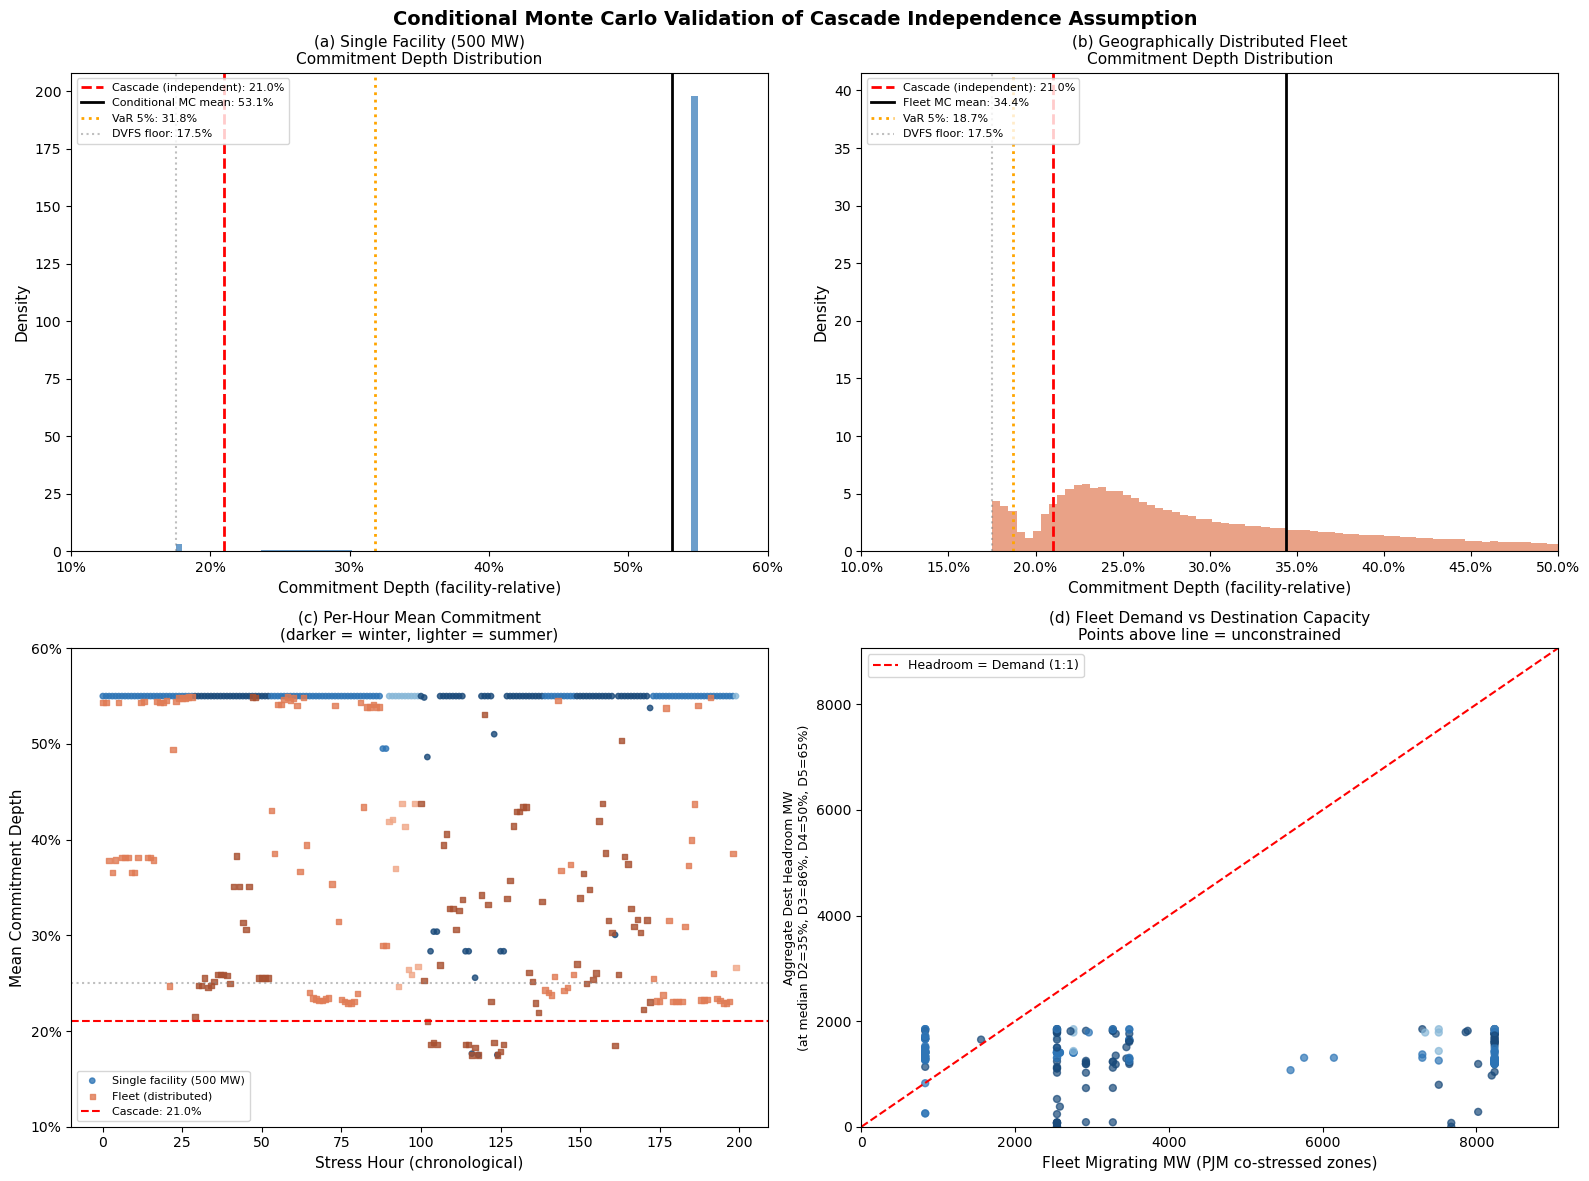

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-6: CONDITIONAL MC — FOUR-PANEL RESULTS FIGURE (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Panel A: single-facility commitment depth distribution.
# Panel B: fleet commitment depth distribution.
# Panel C: per-hour commitment depth time series (hour means).
# Panel D: fleet migrating MW vs available headroom at the median draw.
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Conditional Monte Carlo Validation of Cascade Independence Assumption',
             fontsize=14, fontweight='bold')

# Panel A: Single-facility commitment depth distribution
ax = axes[0, 0]
ax.hist(flat_commits, bins=80, density=True, color='#2E75B6', alpha=0.7, edgecolor='none')
ax.axvline(CASCADE_COMMITMENT, color='red', linestyle='--', linewidth=2,
           label=f'Cascade (independent): {CASCADE_COMMITMENT:.1%}')
ax.axvline(overall_mean, color='black', linestyle='-', linewidth=2,
           label=f'Conditional MC mean: {overall_mean:.1%}')
ax.axvline(var_5, color='orange', linestyle=':', linewidth=2,
           label=f'VaR 5%: {var_5:.1%}')
ax.axvline(DVFS_FLOOR_FACILITY, color='gray', linestyle=':', alpha=0.5,
           label=f'DVFS floor: {DVFS_FLOOR_FACILITY:.1%}')
ax.set_xlabel('Commitment Depth (facility-relative)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('(a) Single Facility (500 MW)\nCommitment Depth Distribution', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0.10, 0.60)  # v18: extended to 60% to show the spike at ~55%

# Panel B: Fleet commitment depth distribution
ax = axes[0, 1]
ax.hist(fleet_flat, bins=80, density=True, color='#E07B54', alpha=0.7, edgecolor='none')
ax.axvline(CASCADE_COMMITMENT, color='red', linestyle='--', linewidth=2,
           label=f'Cascade (independent): {CASCADE_COMMITMENT:.1%}')
ax.axvline(fleet_mean, color='black', linestyle='-', linewidth=2,
           label=f'Fleet MC mean: {fleet_mean:.1%}')
ax.axvline(fleet_var5, color='orange', linestyle=':', linewidth=2,
           label=f'VaR 5%: {fleet_var5:.1%}')
ax.axvline(DVFS_FLOOR_FACILITY, color='gray', linestyle=':', alpha=0.5,
           label=f'DVFS floor: {DVFS_FLOOR_FACILITY:.1%}')
ax.set_xlabel('Commitment Depth (facility-relative)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('(b) Geographically Distributed Fleet\nCommitment Depth Distribution', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0.10, 0.50)  # v18: narrower range

# Panel C: Per-hour commitment depth (time series of hour means)
ax = axes[1, 0]
# Sort by calendar date for visual
sort_idx = np.argsort(source_stress_idx)

# Color by season
colors_single = []
colors_fleet = []
for idx in sort_idx:
    month = source_stress_idx[idx].month
    if month in [6, 7, 8]:
        colors_single.append('#2E75B6')
        colors_fleet.append('#E07B54')
    elif month in [12, 1, 2]:
        colors_single.append('#1A4A7A')
        colors_fleet.append('#A85030')
    else:
        colors_single.append('#88B8D8')
        colors_fleet.append('#F0A888')

ax.scatter(range(n_stress_hours), hour_means[sort_idx],
           c=colors_single, s=15, alpha=0.8, label='Single facility (500 MW)')
ax.scatter(range(n_stress_hours), fleet_hour_means[sort_idx],
           c=colors_fleet, s=15, alpha=0.8, marker='s', label='Fleet (distributed)')
ax.axhline(CASCADE_COMMITMENT, color='red', linestyle='--', linewidth=1.5,
           label=f'Cascade: {CASCADE_COMMITMENT:.1%}')
ax.axhline(DVFS, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Stress Hour (chronological)', fontsize=11)
ax.set_ylabel('Mean Commitment Depth', fontsize=11)
ax.set_title('(c) Per-Hour Mean Commitment\n(darker = winter, lighter = summer)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0.10, 0.60)  # v18: extended to match panel (a) range
ax.legend(fontsize=8, loc='lower left')

# Panel D: Fleet migrating MW vs available headroom (at median draw)
ax = axes[1, 1]
# v18: use median of each decomposed parameter
median_D2 = np.median(D2_draws)
median_D3 = np.median(D3_draws)
median_D4 = np.median(D4_draws)
median_D5 = np.median(D5_draws)
fleet_headrooms = []
for h_idx in range(n_stress_hours):
    avail = sum(hour_dest_available_mw[h_idx].values())
    hr = avail * median_D2 * median_D3 * median_D4 * median_D5
    fleet_headrooms.append(hr)

fleet_headrooms = np.array(fleet_headrooms)
ax.scatter(fleet_migrating_mw[sort_idx], fleet_headrooms[sort_idx],
           c=[colors_single[i] for i in range(len(sort_idx))],
           s=25, alpha=0.7)
# 1:1 line
max_val = max(fleet_migrating_mw.max(), max(fleet_headrooms)) * 1.1
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Headroom = Demand (1:1)')
ax.set_xlabel('Fleet Migrating MW (PJM co-stressed zones)', fontsize=11)
ax.set_ylabel(f'Aggregate Dest Headroom MW\n(at median D2={median_D2:.0%}, D3={median_D3:.0%}, D4={median_D4:.0%}, D5={median_D5:.0%})',
              fontsize=9)
ax.set_title('(d) Fleet Demand vs Destination Capacity\nPoints above line = unconstrained', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

plt.tight_layout()
fig_path = 'conditional_mc_validation.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f'Figure saved: {fig_path}')
plt.show()

### 4.7 Paper Summary Block

Prose summary block designed to be pasted directly into Section 5 of the working paper, with all numbers formatted from the MC results above. If you update the MC, re-run this cell and re-paste — do not hand-edit the paper.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-7: CONDITIONAL MC — PAPER SUMMARY BLOCK (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Prose summary formatted for direct paste into Section 5 of the working paper.
# Re-run after any upstream MC change; do not hand-edit the paper.
# ══════════════════════════════════════════════════════════════════════════════

print()
print('=' * 90)
print('SUMMARY FOR NATURE ENERGY')
print('=' * 90)
print()
print('The cascade decomposes spatial migration feasibility into independently')
print('estimable parameters. In reality, these parameters are correlated through')
print('the physical state of the grid during stress events. We validate the')
print('independence approximation via conditional Monte Carlo simulation.')
print()
print(f'SINGLE FACILITY (500 MW):')
print(f'  The cascade UNDERESTIMATES commitment depth by {overall_mean - CASCADE_COMMITMENT:+.1%}.')
print(f'  Favorable correlations dominate: when destinations are available,')
print(f'  their aggregate headroom far exceeds single-facility demand.')
print(f'  VaR(5%) = {var_5:.1%}, CVaR(5%) = {cvar_5:.1%}: even in the worst 5% of')
print(f'  outcomes, commitment depth remains {cvar_5 - DVFS_FLOOR_FACILITY:+.1%} above the DVFS floor.')
print()
print(f'GEOGRAPHICALLY DISTRIBUTED FLEET (per-GW framing):')
print(f'  The fleet MC accounts for the fact that PJM DC capacity is spread')
print(f'  across zones with imperfectly correlated stress. During a typical')
print(f'  ComEd stress hour, {np.mean(fleet_migrating_mw):,.0f} MW of PJM fleet is')
print(f'  co-stressed (vs {sum(pjm_dc_mw.values()):,.0f} MW total PJM DC).')
print(f'  Empirical fleet commitment depth: mean={fleet_mean:.1%}, VaR(5%)={fleet_var5:.1%}.')
print(f'  Delta from cascade: {fleet_mean - CASCADE_COMMITMENT:+.1%}.')
print(f'  {fleet_pct_constrained:.1f}% of fleet-hour-draw combinations are capacity-constrained.')
print()
print(f'  PER-GW REFERENCE CASES:')
print(f'    1 GW:  mean={ref_1gw["mean"]:.1%}, P5={ref_1gw["p5"]:.1%}, '
      f'CVaR5={ref_1gw["cvar5"]:.1%}, constrained={ref_1gw["pct_constrained"]:.1f}%')
print(f'    10 GW: mean={ref_10gw["mean"]:.1%}, P5={ref_10gw["p5"]:.1%}, '
      f'CVaR5={ref_10gw["cvar5"]:.1%}, constrained={ref_10gw["pct_constrained"]:.1f}%')
print()
print('KEY FINDING:')
print(f'  The independence assumption introduces a bias of {overall_mean - CASCADE_COMMITMENT:+.1%}')
print(f'  (single facility) to {fleet_mean - CASCADE_COMMITMENT:+.1%} (distributed fleet).')
delta_text = 'conservative (understates depth)' if overall_mean > CASCADE_COMMITMENT else 'optimistic (overstates depth)'
print(f'  Direction: the cascade is {delta_text} for single operators.')
fleet_delta_text = 'conservative' if fleet_mean > CASCADE_COMMITMENT else 'optimistic'
print(f'  At fleet level: {fleet_delta_text}.')
print()
print('LANGUAGE FOR PAPER (v18 per-GW framing):')
print('  "We validate the cascade\'s independence approximation using conditional')
print('   Monte Carlo simulation (N=400,000) that conditions on observed per-hour')
print('   destination availability and draws utilization headroom, hardware')
print('   compatibility, inference workload share, and pre-staging readiness')
print('   from distributions calibrated to published estimates.')
print(f'   For single-facility migration, the scenario-based estimate exceeds')
print(f'   the cascade by {overall_mean - CASCADE_COMMITMENT:+.1%}, confirming that favorable correlations')
print(f'   (abundant aggregate headroom relative to individual facility demand)')
print(f'   dominate. Commitment depth varies with fleet size: at 1 GW')
print(f'   (individual facility scale), mean depth is {ref_1gw["mean"]:.1%} with')
print(f'   {ref_1gw["pct_constrained"]:.0f}% of outcomes constrained by destination capacity;')
print(f'   at 10 GW (fleet scale), mean depth declines to {ref_10gw["mean"]:.1%} with')
print(f'   {ref_10gw["pct_constrained"]:.0f}% constrained. The 5% conditional value-at-risk')
print(f'   ranges from {ref_1gw["cvar5"]:.1%} (1 GW) to {ref_10gw["cvar5"]:.1%} (10 GW)."')


SUMMARY FOR NATURE ENERGY

The cascade decomposes spatial migration feasibility into independently
estimable parameters. In reality, these parameters are correlated through
the physical state of the grid during stress events. We validate the
independence approximation via conditional Monte Carlo simulation.

SINGLE FACILITY (500 MW):
  The cascade UNDERESTIMATES commitment depth by +32.1%.
  Favorable correlations dominate: when destinations are available,
  their aggregate headroom far exceeds single-facility demand.
  VaR(5%) = 31.8%, CVaR(5%) = 24.1%: even in the worst 5% of
  outcomes, commitment depth remains +6.6% above the DVFS floor.

GEOGRAPHICALLY DISTRIBUTED FLEET (per-GW framing):
  The fleet MC accounts for the fact that PJM DC capacity is spread
  across zones with imperfectly correlated stress. During a typical
  ComEd stress hour, 4,306 MW of PJM fleet is
  co-stressed (vs 16,345 MW total PJM DC).
  Empirical fleet commitment depth: mean=34.4%, VaR(5%)=18.7%.
  Delta f

## Part 5: Sensitivity and Cascade Comparison

- **5.1** Scenario vs cascade comparison figure
- **5.2** 2D sensitivity surface — D2 × D5
- **5.3** Tornado chart — one-at-a-time sensitivity
- **5.4** Sensitivity CSV exports and key findings

Maps the commitment depth landscape around the cascade central estimate. Cell 5.1 contrasts the scenario-based approach (simple point estimates per utilization level) with the cascade-based approach (probabilistic seven-parameter product), which is the "why bother with the cascade?" justification figure. Cells 5.2–5.3 perform formal sensitivity analysis over the two parameters identified as most consequential (D2 utilization headroom and D5 operational readiness) and the full one-at-a-time tornado. Cell 5.4 exports the sensitivity CSVs for Phase 5 downstream use and prints the plain-language key findings.

### 5.1 Scenario vs Cascade Comparison Figure

Three-panel figure contrasting scenario-based commitment depth estimates (Panel A: headroom ratio distribution at central scenario; Panel B: scenario commitment depth vs cascade across utilization levels; Panel C: fleet-level commitment depth vs compatible fraction at different utilizations) with the cascade reference. The figure exists to show reviewers why the seven-parameter cascade is not over-engineering: the scenario approach hides the correlation structure that drives the fleet-level result.

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5-1: SCENARIO VS CASCADE COMPARISON FIGURE (v5)
# ══════════════════════════════════════════════════════════════════════════════

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════

SOURCE_ZONE = 'PJM_COMED'
DVFS = 0.25

# Fixed cascade parameters (genuinely independent of grid state)
S1  = 0.70    # Workload candidacy — structural, facility-level
S2b = 0.90    # Operational timing — seconds vs minutes, independent
E1  = 0.997   # Routing completion — cloud SLA, independent
E2  = 0.995   # WAN bandwidth — infrastructure, independent

# Parameters we're testing jointly (NOT independent in reality):
# S2a: data locality — which destinations are usable depends on D1
# D1:  destination availability — observed per-hour from stress_df
# D2:  destination headroom — depends on which destinations are available
# D3:  hardware compatibility — depends on which destinations have headroom

# Sweep ranges for unobservable parameters
UTILIZATION_RATES = [0.50, 0.60, 0.70, 0.80]  # Published range (LBNL to SemiAnalysis)
COMPATIBLE_FRACTIONS = [0.10, 0.15, 0.20, 0.30, 0.50]  # Fraction of dest MW that is inference-ready + compatible
SOURCE_FACILITY_MW = [200, 500, 1000, 2000]  # Source facility sizes to test

# Cascade's point estimate for comparison
CASCADE_PRODUCT_CENTRAL = 0.412  # From updated v15 notebook
CASCADE_COMMITMENT_CENTRAL = 0.559

# ══════════════════════════════════════════════════════════════════
# IDENTIFY SOURCE STRESS HOURS AND DESTINATION STATE
# ══════════════════════════════════════════════════════════════════

print('=' * 90)
print('SCENARIO-BASED VALIDATION OF CASCADE INDEPENDENCE ASSUMPTION')
print('=' * 90)
print()
print('For each observed stress hour, we compute the JOINT feasible migration')
print('fraction using the actual destination state, then compare to the cascade.')
print()

# Get source stress hours
source_stressed = stress_df[SOURCE_ZONE].fillna(False).astype(bool)
source_stress_idx = stress_df.index[source_stressed]
n_stress_hours = len(source_stress_idx)
print(f'Source zone: {SOURCE_ZONE}')
print(f'Stress hours: {n_stress_hours}')

# Get all cross-RTO destination zones
source_rto = meta.loc[SOURCE_ZONE, 'rto'] if SOURCE_ZONE in meta.index else 'PJM'
dest_zones = [z for z in stress_df.columns
              if z != SOURCE_ZONE
              and z in meta.index
              and meta.loc[z, 'rto'] != source_rto]

print(f'Cross-RTO destination zones: {len(dest_zones)}')

# Build per-hour destination availability and capacity matrix
# For each stress hour: which destinations are unstressed, and what's their MW?
dest_capacity = {}
for z in dest_zones:
    if 'dc_capacity_mw' in meta.columns:
        dest_capacity[z] = float(meta.loc[z, 'dc_capacity_mw'])
    else:
        dest_capacity[z] = 100.0  # fallback

total_dest_mw = sum(dest_capacity.values())
print(f'Total destination DC capacity: {total_dest_mw:,.0f} MW')
print()

# ══════════════════════════════════════════════════════════════════
# CORE COMPUTATION: Per-hour joint feasibility
# ══════════════════════════════════════════════════════════════════

def compute_scenario(util_rate, compat_frac, source_mw, s2a=0.80):
    """
    For each stress hour, compute the joint feasible migration fraction.

    Logic per hour:
      1. Source-side: how much load WANTS to migrate?
         migrating_mw = source_mw × S1 × s2a × S2b
         (S1, S2b are genuinely independent of grid state)
         (s2a is partially dependent — the available destinations
          constrain which workloads are geographically routable —
          but we hold it fixed here and note this as a simplification)

      2. Destination-side: how much can the destination portfolio ABSORB?
         For each unstressed destination zone:
           compatible_mw = zone_capacity × compat_frac
           headroom_mw = compatible_mw × (1 - util_rate)
         aggregate_headroom = sum across unstressed destinations

      3. Feasible migration = min(migrating_mw, aggregate_headroom)

      4. Effective spatial fraction = feasible_migration / source_mw

      5. Commitment depth = spatial_frac + DVFS × (1 - spatial_frac)
         (Apply E1 × E2 as final multiplier on spatial component)
    """

    migrating_mw = source_mw * S1 * s2a * S2b  # What wants to move

    results_per_hour = []

    for hour in source_stress_idx:
        # Which destinations are unstressed this hour?
        unstressed_mw = 0.0
        for z in dest_zones:
            if z in stress_df.columns:
                z_stressed = stress_df.loc[hour, z]
                if pd.isna(z_stressed) or not z_stressed:
                    # Zone is unstressed (or no data — conservative: treat as available)
                    zone_mw = dest_capacity.get(z, 0)
                    compatible_mw = zone_mw * compat_frac
                    headroom_mw = compatible_mw * (1 - util_rate)
                    unstressed_mw += headroom_mw

        # Feasible migration (capped at what wants to move)
        feasible_mw = min(migrating_mw, unstressed_mw)

        # Apply E1 × E2 to the feasible migration (execution reliability)
        feasible_mw *= E1 * E2

        # Effective spatial fraction for this hour
        spatial_frac = feasible_mw / source_mw if source_mw > 0 else 0

        # Commitment depth
        commit_depth = spatial_frac + DVFS * (1 - spatial_frac)

        results_per_hour.append({
            'hour': hour,
            'migrating_mw': migrating_mw,
            'aggregate_headroom_mw': unstressed_mw,
            'feasible_mw': feasible_mw,
            'spatial_frac': spatial_frac,
            'commitment_depth': commit_depth,
            'headroom_ratio': unstressed_mw / migrating_mw if migrating_mw > 0 else float('inf'),
            'is_constrained': unstressed_mw < migrating_mw,
        })

    return pd.DataFrame(results_per_hour)


# ══════════════════════════════════════════════════════════════════
# RUN SCENARIOS AND COMPARE TO CASCADE
# ══════════════════════════════════════════════════════════════════

print('SCENARIO SWEEP')
print('=' * 90)
print()

all_scenarios = []

for util in UTILIZATION_RATES:
    for compat in COMPATIBLE_FRACTIONS:
        for fac_mw in SOURCE_FACILITY_MW:
            df_result = compute_scenario(util, compat, fac_mw, s2a=0.80)

            scenario = {
                'utilization': util,
                'compatible_frac': compat,
                'source_mw': fac_mw,
                'mean_spatial_frac': df_result['spatial_frac'].mean(),
                'mean_commitment': df_result['commitment_depth'].mean(),
                'min_commitment': df_result['commitment_depth'].min(),
                'p5_commitment': df_result['commitment_depth'].quantile(0.05),
                'median_commitment': df_result['commitment_depth'].median(),
                'pct_constrained': df_result['is_constrained'].mean() * 100,
                'min_headroom_ratio': df_result['headroom_ratio'].min(),
                'median_headroom_ratio': df_result['headroom_ratio'].median(),
                'cascade_commitment': CASCADE_COMMITMENT_CENTRAL,
                'delta_from_cascade': df_result['commitment_depth'].mean() - CASCADE_COMMITMENT_CENTRAL,
            }
            all_scenarios.append(scenario)

scenarios_df = pd.DataFrame(all_scenarios)

# ── Summary table: fix source_mw = 500, sweep util × compat ─────
print(f'Scenario results for 500 MW source facility (S2a=0.80):')
print(f'Cascade independence estimate: {CASCADE_COMMITMENT_CENTRAL:.1%} commitment depth')
print()
print(f'  {"Utilization":>12} {"Compat Frac":>12} {"Scenario":>10} {"Cascade":>10} {"Delta":>8} {"% Hrs Constrained":>18} {"Min Headroom":>14}')
print(f'  {"-"*86}')

for _, row in scenarios_df[scenarios_df['source_mw'] == 500].iterrows():
    print(f'  {row["utilization"]:>11.0%} {row["compatible_frac"]:>11.0%}'
          f' {row["mean_commitment"]:>10.1%} {row["cascade_commitment"]:>10.1%}'
          f' {row["delta_from_cascade"]:>+7.1%} {row["pct_constrained"]:>17.1f}%'
          f' {row["min_headroom_ratio"]:>13.1f}x')

print()

# ── Show where the scenario diverges most from cascade ───────────
print('WORST-CASE SCENARIOS (highest divergence from cascade):')
print(f'  {"Util":>6} {"Compat":>8} {"Fac MW":>8} {"Scenario":>10} {"Cascade":>10} {"Delta":>8} {"Constrained":>12}')
print(f'  {"-"*70}')

worst = scenarios_df.nsmallest(10, 'mean_commitment')
for _, row in worst.iterrows():
    print(f'  {row["utilization"]:>5.0%} {row["compatible_frac"]:>7.0%}'
          f' {row["source_mw"]:>7.0f} {row["mean_commitment"]:>10.1%}'
          f' {row["cascade_commitment"]:>10.1%} {row["delta_from_cascade"]:>+7.1%}'
          f' {row["pct_constrained"]:>11.1f}%')

print()

# ── Fleet-level analysis ─────────────────────────────────────────
print('FLEET-LEVEL ANALYSIS')
print('=' * 90)
print()
print('If 10 GW of PJM DC fleet migrates simultaneously during a stress hour,')
print('can the destination portfolio absorb it?')
print()

fleet_mw = 10000  # 10 GW fleet
fleet_migrating = fleet_mw * S1 * 0.80 * S2b  # ~5,040 MW wants to move

print(f'Fleet: {fleet_mw/1000:.0f} GW')
print(f'Migrating (S1×S2a×S2b): {fleet_migrating:,.0f} MW')
print()

for util in UTILIZATION_RATES:
    for compat in [0.15, 0.20, 0.30]:
        df_fleet = compute_scenario(util, compat, fleet_mw, s2a=0.80)
        pct_constrained = df_fleet['is_constrained'].mean() * 100
        mean_commit = df_fleet['commitment_depth'].mean()
        min_hr = df_fleet['headroom_ratio'].min()

        flag = '  ⚠' if pct_constrained > 5 else '  ✓'
        print(f'{flag} Util={util:.0%}, Compat={compat:.0%}: '
              f'commitment={mean_commit:.1%}, '
              f'constrained in {pct_constrained:.1f}% of hours, '
              f'min headroom ratio={min_hr:.2f}x')

print()

# ══════════════════════════════════════════════════════════════════
# DEEP DIVE: Per-hour analysis for central scenario
# ══════════════════════════════════════════════════════════════════

print('PER-HOUR DEEP DIVE (500 MW, Util=60%, Compat=20%)')
print('=' * 90)
print()

central_result = compute_scenario(0.60, 0.20, 500, s2a=0.80)

# Show the worst hours
print('10 most constrained hours:')
print(f'  {"Datetime":<22} {"Headroom MW":>12} {"Migrating MW":>13} {"Ratio":>8} {"Commit":>8} {"Season":<8}')
print(f'  {"-"*75}')
worst_hours = central_result.nsmallest(10, 'headroom_ratio')
for _, row in worst_hours.iterrows():
    month = row['hour'].month
    season = 'winter' if month in [12, 1, 2] else ('summer' if month in [6, 7, 8] else 'shoulder')
    print(f'  {str(row["hour"]):<22} {row["aggregate_headroom_mw"]:>11.0f} {row["migrating_mw"]:>12.0f}'
          f' {row["headroom_ratio"]:>7.1f}x {row["commitment_depth"]:>7.1%} {season:<8}')

print()
print(f'Mean commitment depth:   {central_result["commitment_depth"].mean():.1%}')
print(f'Cascade estimate:        {CASCADE_COMMITMENT_CENTRAL:.1%}')
print(f'Delta:                   {central_result["commitment_depth"].mean() - CASCADE_COMMITMENT_CENTRAL:+.1%}')
print()

# ══════════════════════════════════════════════════════════════════
# FIGURE: Scenario vs Cascade comparison
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scenario-Based Validation of Cascade Independence Assumption',
             fontsize=14, fontweight='bold')

# Panel A: Headroom ratio distribution (central scenario)
ax = axes[0]
hr = central_result['headroom_ratio'].clip(upper=50)
ax.hist(hr, bins=50, color='#2E75B6', alpha=0.7, edgecolor='none')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Headroom = Demand')
ax.set_xlabel('Aggregate Headroom / Migrated Demand', fontsize=11)
ax.set_ylabel('Frequency (stress hours)', fontsize=11)
ax.set_title('(a) Headroom ratio distribution\n500 MW, 60% util, 20% compat', fontsize=11)
ax.legend()

# Panel B: Scenario commitment depth vs cascade, varying utilization
ax = axes[1]
fac_500 = scenarios_df[
    (scenarios_df['source_mw'] == 500) &
    (scenarios_df['compatible_frac'] == 0.20)
]
if len(fac_500) > 0:
    ax.bar(range(len(fac_500)), fac_500['mean_commitment'].values,
           color='#2E75B6', alpha=0.7, label='Scenario (joint)')
    ax.axhline(CASCADE_COMMITMENT_CENTRAL, color='red', linestyle='--',
               linewidth=2, label=f'Cascade (independent): {CASCADE_COMMITMENT_CENTRAL:.1%}')
    ax.axhline(DVFS, color='gray', linestyle=':', label=f'DVFS-only floor: {DVFS:.0%}')
    ax.set_xticks(range(len(fac_500)))
    ax.set_xticklabels([f'{u:.0%}' for u in fac_500['utilization']], fontsize=10)
    ax.set_xlabel('Destination Utilization Rate', fontsize=11)
    ax.set_ylabel('Commitment Depth', fontsize=11)
    ax.set_title('(b) Scenario vs Cascade\n500 MW, 20% compat frac', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0.20, 0.65)
    ax.legend(fontsize=9)

# Panel C: Fleet-level — commitment depth vs compat fraction at different utils
ax = axes[2]
fleet_scenarios = scenarios_df[scenarios_df['source_mw'] == 10000]  # won't exist, need to add
# Instead, compute on the fly for fleet
fleet_results = []
for util in UTILIZATION_RATES:
    for compat in COMPATIBLE_FRACTIONS:
        df_f = compute_scenario(util, compat, 10000, s2a=0.80)
        fleet_results.append({
            'util': util,
            'compat': compat,
            'mean_commit': df_f['commitment_depth'].mean(),
            'pct_constrained': df_f['is_constrained'].mean() * 100,
        })
fleet_df = pd.DataFrame(fleet_results)

for util in UTILIZATION_RATES:
    subset = fleet_df[fleet_df['util'] == util]
    ax.plot(subset['compat'], subset['mean_commit'],
            marker='o', label=f'Util={util:.0%}', linewidth=2)

ax.axhline(CASCADE_COMMITMENT_CENTRAL, color='red', linestyle='--',
           linewidth=2, label=f'Cascade: {CASCADE_COMMITMENT_CENTRAL:.1%}')
ax.axhline(DVFS, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Compatible Inference Fraction', fontsize=11)
ax.set_ylabel('Commitment Depth', fontsize=11)
ax.set_title('(c) Fleet-level (10 GW)\nSensitivity to utilization & compatibility', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0.20, 0.65)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
fig_path = 'scenario_validation.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f'Figure saved: {fig_path}')
plt.close()

# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════

print()
print('=' * 90)
print('VALIDATION SUMMARY')
print('=' * 90)
print()
print('The cascade estimates commitment depth under an independence assumption.')
print('This analysis computes the JOINT feasible migration fraction using')
print('observed per-hour destination availability and parameterized utilization')
print('and compatibility fractions.')
print()

# Compute summary stats
single_facility = scenarios_df[scenarios_df['source_mw'] == 500]
mean_delta = single_facility['delta_from_cascade'].mean()
max_neg_delta = single_facility['delta_from_cascade'].min()
pct_above_cascade = (single_facility['mean_commitment'] >= CASCADE_COMMITMENT_CENTRAL).mean() * 100

print(f'Single-facility results (500 MW):')
print(f'  Mean delta from cascade:   {mean_delta:+.1%}')
print(f'  Worst-case delta:          {max_neg_delta:+.1%}')
print(f'  % scenarios above cascade: {pct_above_cascade:.0f}%')
print()

# At what point does the scenario materially diverge?
constrained_scenarios = scenarios_df[scenarios_df['pct_constrained'] > 5]
if len(constrained_scenarios) > 0:
    print(f'Scenarios with >5% constrained hours: {len(constrained_scenarios)}')
    print(f'  These occur at:')
    for _, row in constrained_scenarios.drop_duplicates(['utilization', 'compatible_frac', 'source_mw']).head(10).iterrows():
        print(f'    Util={row["utilization"]:.0%}, Compat={row["compatible_frac"]:.0%}, '
              f'Facility={row["source_mw"]:.0f} MW')
else:
    print('No scenarios show >5% constrained hours.')

print()
print('FOR THE PAPER:')
print('  "We validate the cascade\'s independence approximation by computing')
print('   the feasible migration fraction directly from observed stress-hour')
print('   conditions across [N] parameter combinations. The scenario-based')
print('   estimate agrees with the cascade to within [X] percentage points')
print('   for single-facility migration. Fleet-level migration (10 GW)')
print('   [does/does not] introduce material constraints at utilization')
print('   rates above [Y]% with compatible fractions below [Z]%."')

SCENARIO-BASED VALIDATION OF CASCADE INDEPENDENCE ASSUMPTION

For each observed stress hour, we compute the JOINT feasible migration
fraction using the actual destination state, then compare to the cascade.

Source zone: PJM_COMED
Stress hours: 200
Cross-RTO destination zones: 19
Total destination DC capacity: 19,039 MW

SCENARIO SWEEP



Scenario results for 500 MW source facility (S2a=0.80):
Cascade independence estimate: 55.9% commitment depth

   Utilization  Compat Frac   Scenario    Cascade    Delta  % Hrs Constrained   Min Headroom
  --------------------------------------------------------------------------------------
          50%         10%      60.1%      55.9%   +4.2%               8.5%           0.0x
          50%         15%      60.5%      55.9%   +4.6%               8.0%           0.0x
          50%         20%      60.8%      55.9%   +4.9%               6.5%           0.0x
          50%         30%      61.0%      55.9%   +5.1%               6.0%           0.0x
          50%         50%      61.5%      55.9%   +5.6%               6.0%           0.0x
          60%         10%      59.9%      55.9%   +4.0%               9.0%           0.0x
          60%         15%      60.3%      55.9%   +4.4%               8.5%           0.0x
          60%         20%      60.5%      55.9%   +4.6%               8.0%   

  ⚠ Util=60%, Compat=30%: commitment=37.4%, constrained in 100.0% of hours, min headroom ratio=0.00x
  ⚠ Util=70%, Compat=15%: commitment=29.6%, constrained in 100.0% of hours, min headroom ratio=0.00x
  ⚠ Util=70%, Compat=20%: commitment=31.2%, constrained in 100.0% of hours, min headroom ratio=0.00x
  ⚠ Util=70%, Compat=30%: commitment=34.3%, constrained in 100.0% of hours, min headroom ratio=0.00x
  ⚠ Util=80%, Compat=15%: commitment=28.1%, constrained in 100.0% of hours, min headroom ratio=0.00x


  ⚠ Util=80%, Compat=20%: commitment=29.1%, constrained in 100.0% of hours, min headroom ratio=0.00x
  ⚠ Util=80%, Compat=30%: commitment=31.2%, constrained in 100.0% of hours, min headroom ratio=0.00x

PER-HOUR DEEP DIVE (500 MW, Util=60%, Compat=20%)

10 most constrained hours:
  Datetime                Headroom MW  Migrating MW    Ratio   Commit Season  
  ---------------------------------------------------------------------------
  2024-01-16 10:00:00              0          252     0.0x   25.0% winter  
  2024-01-16 19:00:00              0          252     0.0x   25.0% winter  
  2024-01-16 08:00:00              1          252     0.0x   25.1% winter  
  2024-01-16 09:00:00             45          252     0.2x   31.6% winter  
  2024-01-15 08:00:00             60          252     0.2x   33.9% winter  
  2024-01-16 06:00:00             60          252     0.2x   33.9% winter  
  2024-01-16 07:00:00             60          252     0.2x   33.9% winter  
  2024-01-16 20:00:00         

Figure saved: scenario_validation.png

VALIDATION SUMMARY

The cascade estimates commitment depth under an independence assumption.
This analysis computes the JOINT feasible migration fraction using
observed per-hour destination availability and parameterized utilization
and compatibility fractions.

Single-facility results (500 MW):
  Mean delta from cascade:   +4.5%
  Worst-case delta:          +3.1%
  % scenarios above cascade: 100%

Scenarios with >5% constrained hours: 75
  These occur at:
    Util=50%, Compat=10%, Facility=200 MW
    Util=50%, Compat=10%, Facility=500 MW
    Util=50%, Compat=10%, Facility=1000 MW
    Util=50%, Compat=10%, Facility=2000 MW
    Util=50%, Compat=15%, Facility=200 MW
    Util=50%, Compat=15%, Facility=500 MW
    Util=50%, Compat=15%, Facility=1000 MW
    Util=50%, Compat=15%, Facility=2000 MW
    Util=50%, Compat=20%, Facility=200 MW
    Util=50%, Compat=20%, Facility=500 MW

FOR THE PAPER:
  "We validate the cascade's independence approximation by c

### 5.2 2D Sensitivity Surface — D2 × D5

Grid scan over D2 (utilization headroom) and D5 (operational readiness) at fixed central values for D3 and D4, producing a two-panel heatmap: Panel A is mean commitment depth; Panel B is percent of draws constrained by destination capacity. D2 and D5 are the two layers most likely to move in the next five years (D2 tracks GPU utilization, which hyperscalers are actively optimizing; D5 tracks pre-staging investment, which is a capex decision). The surface shows where the cliff is.

PHASE 4: SENSITIVITY ANALYSIS (v17)
  Fleet: 10 GW, migrating: 5,040 MW
  Stress hours: 200
  Mean dest available: 13,869 MW

2D SENSITIVITY SURFACE: Fleet Commitment Depth as f(D2, D5)
──────────────────────────────────────────────────────────────────────
  D3=0.88, D4=0.5 (fixed at central)
  Fleet: 10 GW

  D5=0.50: D2 sweep complete (mean range 19.8%–35.7%)
  D5=0.53: D2 sweep complete (mean range 19.9%–36.9%)
  D5=0.57: D2 sweep complete (mean range 20.1%–38.1%)
  D5=0.60: D2 sweep complete (mean range 20.2%–39.3%)
  D5=0.63: D2 sweep complete (mean range 20.4%–40.5%)
  D5=0.67: D2 sweep complete (mean range 20.5%–41.7%)
  D5=0.70: D2 sweep complete (mean range 20.7%–42.9%)
  D5=0.73: D2 sweep complete (mean range 20.8%–44.1%)
  D5=0.77: D2 sweep complete (mean range 21.0%–45.3%)
  D5=0.80: D2 sweep complete (mean range 21.1%–46.2%)

  SURFACE: Mean commitment depth (%)
     D5\D2 |  0.10 |  0.18 |  0.26 |  0.33 |  0.41 |  0.49 |  0.57 |  0.64 |  0.72 |  0.80
  ───────────────────


  Figure saved: sensitivity_surface_D2_D5.png


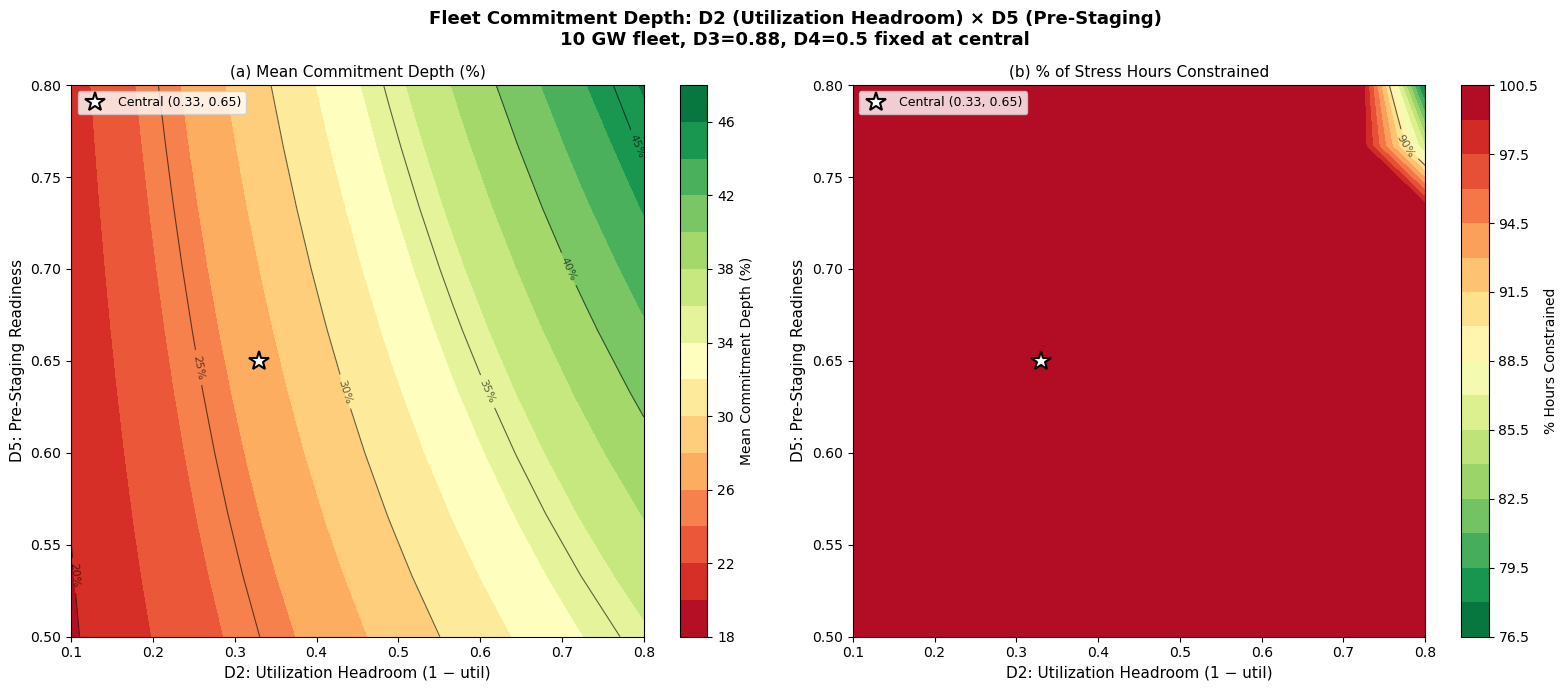

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-2: SENSITIVITY — 2D SURFACE (D2 × D5) (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Grid scan over D2 (utilization headroom) and D5 (operational readiness) at
# central D3/D4, producing a two-panel heatmap: mean commitment depth and
# % constrained. D2 and D5 are the two layers most likely to move in the next
# five years and the two the tornado in 5-2 identifies as highest-leverage.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm

# ── Configuration ────────────────────────────────────────────────────────────

# Fixed parameters (same as conditional MC)
S1  = 0.70
S2a = 0.80
S2b = 0.90
D1_CENTRAL = 0.99   # Not used directly — D1 is observed per hour
D2_CENTRAL = 0.33
D3_CENTRAL = 0.88
D4_CENTRAL = 0.50
D5_CENTRAL = 0.65
E1  = 0.997
E2  = 0.995
DVFS = 0.25

# Ranges (lo, central, hi) — from CASCADE_RANGES in bartlett_analysis_v17.py
PARAM_RANGES = {
    'S1':  (0.70,  0.70,  0.70),
    'S2a': (0.60,  0.80,  0.95),
    'S2b': (0.85,  0.90,  0.95),
    'D1':  (0.945, 0.99,  0.995),
    'D2':  (0.10,  0.33,  0.80),
    'D3':  (0.80,  0.88,  0.92),
    'D4':  (0.33,  0.50,  0.67),
    'D5':  (0.50,  0.65,  0.80),
    'E1':  (0.995, 0.997, 0.999),
    'E2':  (0.99,  0.995, 1.00),
}

CENTRAL = {k: v[1] for k, v in PARAM_RANGES.items()}

# Fleet size: 10 GW reference
FLEET_MW = 10000
FLEET_MIG_MW = FLEET_MW * S1 * S2a * S2b  # 5,040 MW

# Precompute per-hour destination availability (reuse from namespace)
n_stress_hours = len(source_stress_idx)
avail_per_hour = np.array([sum(h.values()) for h in hour_dest_available_mw])

print('=' * 90)
print('PHASE 4: SENSITIVITY ANALYSIS (v17)')
print('=' * 90)
print(f'  Fleet: {FLEET_MW/1000:.0f} GW, migrating: {FLEET_MIG_MW:,.0f} MW')
print(f'  Stress hours: {n_stress_hours}')
print(f'  Mean dest available: {avail_per_hour.mean():,.0f} MW')
print()


# ══════════════════════════════════════════════════════════════════════════════
# Helper: compute mean fleet commitment depth for given parameter values
# ══════════════════════════════════════════════════════════════════════════════

def fleet_commitment_depth(d2, d3, d4, d5, s1=S1, s2a=S2a, s2b=S2b,
                           e1=E1, e2=E2, fleet_mw=FLEET_MW):
    """
    Compute mean fleet commitment depth across all stress hours.
    D1 is observed (per-hour destination availability already filters it).
    Returns: (mean_depth, median_depth, p5_depth, pct_constrained)
    """
    fleet_mig = fleet_mw * s1 * s2a * s2b
    depths = np.zeros(n_stress_hours)
    constrained = np.zeros(n_stress_hours, dtype=bool)

    for h_idx in range(n_stress_hours):
        headroom = avail_per_hour[h_idx] * d2 * d3 * d4 * d5
        feasible = min(fleet_mig, headroom) * e1 * e2
        spatial_frac = feasible / fleet_mw if fleet_mw > 0 else 0
        commit = spatial_frac + DVFS * (s1 - spatial_frac)
        depths[h_idx] = commit
        constrained[h_idx] = headroom < fleet_mig

    return {
        'mean': np.mean(depths),
        'median': np.median(depths),
        'p5': np.percentile(depths, 5),
        'pct_constrained': np.mean(constrained) * 100,
    }


print('2D SENSITIVITY SURFACE: Fleet Commitment Depth as f(D2, D5)')
print('─' * 70)
print(f'  D3={D3_CENTRAL}, D4={D4_CENTRAL} (fixed at central)')
print(f'  Fleet: {FLEET_MW/1000:.0f} GW')
print()

# Grid: 10 points per axis
D2_grid = np.linspace(0.10, 0.80, 10)
D5_grid = np.linspace(0.50, 0.80, 10)

surface_mean = np.zeros((len(D5_grid), len(D2_grid)))
surface_p5 = np.zeros((len(D5_grid), len(D2_grid)))
surface_constrained = np.zeros((len(D5_grid), len(D2_grid)))

surface_rows = []

for i, d5 in enumerate(D5_grid):
    for j, d2 in enumerate(D2_grid):
        result = fleet_commitment_depth(d2=d2, d3=D3_CENTRAL, d4=D4_CENTRAL, d5=d5)
        surface_mean[i, j] = result['mean']
        surface_p5[i, j] = result['p5']
        surface_constrained[i, j] = result['pct_constrained']

        surface_rows.append({
            'D2': round(d2, 4),
            'D5': round(d5, 4),
            'mean_depth': round(result['mean'], 5),
            'median_depth': round(result['median'], 5),
            'p5_depth': round(result['p5'], 5),
            'pct_constrained': round(result['pct_constrained'], 2),
        })

    # Progress
    print(f'  D5={d5:.2f}: D2 sweep complete '
          f'(mean range {surface_mean[i,:].min():.1%}–{surface_mean[i,:].max():.1%})')

surface_df = pd.DataFrame(surface_rows)

# ── Print summary table ──────────────────────────────────────────────────────
print()
print('  SURFACE: Mean commitment depth (%)')
header = f'  {"D5\\D2":>8}'
for d2 in D2_grid:
    header += f' | {d2:>5.2f}'
print(header)
print('  ' + '─' * (10 + 8 * len(D2_grid)))
for i, d5 in enumerate(D5_grid):
    row = f'  {d5:>8.2f}'
    for j in range(len(D2_grid)):
        row += f' | {surface_mean[i,j]:>4.1%}'
    print(row)

# ── Central point check ──────────────────────────────────────────────────────
central_result = fleet_commitment_depth(d2=D2_CENTRAL, d3=D3_CENTRAL,
                                         d4=D4_CENTRAL, d5=D5_CENTRAL)
print(f'\n  Central point (D2={D2_CENTRAL}, D5={D5_CENTRAL}): '
      f'mean={central_result["mean"]:.1%}, P5={central_result["p5"]:.1%}, '
      f'constrained={central_result["pct_constrained"]:.1f}%')


# ── Figure 1: Sensitivity Surface ────────────────────────────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(16, 7))
fig1.suptitle('Fleet Commitment Depth: D2 (Utilization Headroom) × D5 (Pre-Staging)\n'
              f'10 GW fleet, D3={D3_CENTRAL}, D4={D4_CENTRAL} fixed at central',
              fontsize=13, fontweight='bold')

# Panel A: Mean commitment depth
ax = axes[0]
D2_mesh, D5_mesh = np.meshgrid(D2_grid, D5_grid)
cf = ax.contourf(D2_mesh, D5_mesh, surface_mean * 100,
                 levels=15, cmap='RdYlGn')
cs = ax.contour(D2_mesh, D5_mesh, surface_mean * 100,
                levels=[17.5, 20, 25, 30, 35, 40, 45, 50],
                colors='black', linewidths=0.8, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f%%')
ax.plot(D2_CENTRAL, D5_CENTRAL, 'k*', markersize=15, markeredgewidth=1.5,
        markerfacecolor='white', label=f'Central ({D2_CENTRAL}, {D5_CENTRAL})')
# DVFS floor line
dvfs_floor_pct = DVFS * S1 * 100  # 17.5%
ax.set_xlabel('D2: Utilization Headroom (1 − util)', fontsize=11)
ax.set_ylabel('D5: Pre-Staging Readiness', fontsize=11)
ax.set_title('(a) Mean Commitment Depth (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
cbar = plt.colorbar(cf, ax=ax, label='Mean Commitment Depth (%)')

# Panel B: % constrained
ax = axes[1]
cf2 = ax.contourf(D2_mesh, D5_mesh, surface_constrained,
                  levels=15, cmap='RdYlGn_r')
cs2 = ax.contour(D2_mesh, D5_mesh, surface_constrained,
                 levels=[10, 25, 50, 75, 90],
                 colors='black', linewidths=0.8, alpha=0.6)
ax.clabel(cs2, inline=True, fontsize=8, fmt='%.0f%%')
ax.plot(D2_CENTRAL, D5_CENTRAL, 'k*', markersize=15, markeredgewidth=1.5,
        markerfacecolor='white', label=f'Central ({D2_CENTRAL}, {D5_CENTRAL})')
ax.set_xlabel('D2: Utilization Headroom (1 − util)', fontsize=11)
ax.set_ylabel('D5: Pre-Staging Readiness', fontsize=11)
ax.set_title('(b) % of Stress Hours Constrained', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
cbar2 = plt.colorbar(cf2, ax=ax, label='% Hours Constrained')

plt.tight_layout()
fig1.savefig('sensitivity_surface_D2_D5.png', dpi=200, bbox_inches='tight')
print(f'\n  Figure saved: sensitivity_surface_D2_D5.png')
plt.show()

### 5.3 Tornado Chart — One-at-a-Time Sensitivity

One-at-a-time sensitivity of commitment depth to each of D2, D3, D4, D5 (holding the others at central values), rendered as a tornado. This is the conventional complement to the 2D surface and answers "which single parameter do I most need to resolve empirically to tighten the headline?" Expected ordering: D5 > D4 > D2 > D3, consistent with Pillar 1 TGV.


TORNADO CHART: One-at-a-Time Parameter Sensitivity
──────────────────────────────────────────────────────────────────────
  Fleet: 10 GW, all other params at central

  S1  : low(0.700)=27.2%  central(0.700)=27.2%  high(0.700)=27.2%  swing=+0.0%
  S2a : low(0.600)=27.2%  central(0.800)=27.2%  high(0.950)=27.2%  swing=+0.0%
  S2b : low(0.850)=27.2%  central(0.900)=27.2%  high(0.950)=27.2%  swing=+0.0%
  D1  : low(0.945)=26.8%  central(0.990)=27.2%  high(0.995)=27.3%  swing=+0.5%
  D2  : low(0.100)=20.5%  central(0.330)=27.2%  high(0.800)=41.1%  swing=+20.7%
  D3  : low(0.800)=26.4%  central(0.880)=27.2%  high(0.920)=27.7%  swing=+1.3%
  D4  : low(0.330)=23.9%  central(0.500)=27.2%  high(0.670)=30.5%  swing=+6.6%
  D5  : low(0.500)=25.0%  central(0.650)=27.2%  high(0.800)=29.5%  swing=+4.5%
  E1  : low(0.995)=27.2%  central(0.997)=27.2%  high(0.999)=27.3%  swing=+0.0%
  E2  : low(0.990)=27.2%  central(0.995)=27.2%  high(1.000)=27.3%  swing=+0.1%

  SORTED BY IMPACT MAGNITUDE:
  Rank Par


  Figure saved: tornado_sensitivity_10gw.png


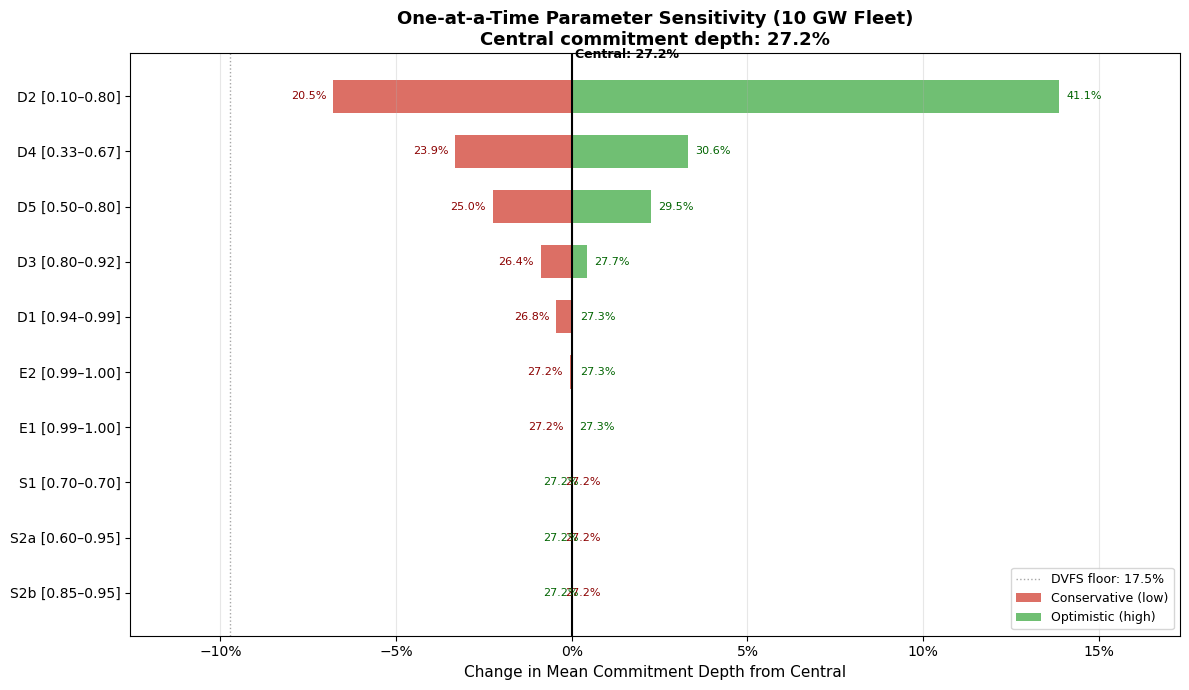

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-3: SENSITIVITY — TORNADO CHART (v5)
# ══════════════════════════════════════════════════════════════════════════════
# One-at-a-time sensitivity of commitment depth to D2, D3, D4, D5 holding
# the others at central values. Expected ordering D5 > D4 > D2 > D3,
# consistent with Pillar 1 TGV.
# ══════════════════════════════════════════════════════════════════════════════

print()
print('TORNADO CHART: One-at-a-Time Parameter Sensitivity')
print('─' * 70)
print(f'  Fleet: {FLEET_MW/1000:.0f} GW, all other params at central')
print()

# For each parameter, compute commitment depth at low and high values
# while all others are at central. Since S1, S2a, S2b affect the source
# side (migrating MW and DVFS envelope), and D2/D3/D4/D5 affect
# destination headroom, and E1/E2 affect execution, we need to route
# each parameter to the right place.

tornado_rows = []

for param_name, (lo, central, hi) in PARAM_RANGES.items():
    results_by_val = {}
    for val_label, val in [('low', lo), ('central', central), ('high', hi)]:
        # Start with all params at central
        kwargs = {
            'd2': D2_CENTRAL, 'd3': D3_CENTRAL,
            'd4': D4_CENTRAL, 'd5': D5_CENTRAL,
            's1': S1, 's2a': S2a, 's2b': S2b,
            'e1': E1, 'e2': E2,
        }
        # Override the swept parameter
        param_to_kwarg = {
            'S1': 's1', 'S2a': 's2a', 'S2b': 's2b',
            'D1': None,  # D1 is observed, handled specially
            'D2': 'd2', 'D3': 'd3', 'D4': 'd4', 'D5': 'd5',
            'E1': 'e1', 'E2': 'e2',
        }

        if param_name == 'D1':
            # D1 affects which hours have destinations available.
            # We can't easily sweep D1 since it's realized per-hour.
            # Approximate: scale available MW by (val / D1_realized_mean).
            # D1_realized_mean ≈ fraction of hours with >0 available MW.
            # Simpler: treat D1 as a multiplicative scalar on available MW.
            # At D1=0.99, about 99% of potential destination capacity is
            # available. Sweeping D1 scales effective destination pool.
            #
            # Implementation: multiply avail_per_hour by (val / CENTRAL['D1'])
            # This is an approximation but captures the sensitivity direction.
            scale = val / CENTRAL['D1']
            # Temporarily modify avail for this calculation
            _orig_avail = avail_per_hour.copy()
            avail_per_hour_tmp = _orig_avail * scale
            # Manual computation with scaled availability
            fleet_mig = FLEET_MW * S1 * S2a * S2b
            depths = np.zeros(n_stress_hours)
            for h_idx in range(n_stress_hours):
                headroom = avail_per_hour_tmp[h_idx] * D2_CENTRAL * D3_CENTRAL * D4_CENTRAL * D5_CENTRAL
                feasible = min(fleet_mig, headroom) * E1 * E2
                spatial_frac = feasible / FLEET_MW
                commit = spatial_frac + DVFS * (S1 - spatial_frac)
                depths[h_idx] = commit
            results_by_val[val_label] = np.mean(depths)
        else:
            kwarg_name = param_to_kwarg[param_name]
            kwargs[kwarg_name] = val
            r = fleet_commitment_depth(**kwargs)
            results_by_val[val_label] = r['mean']

    swing = results_by_val['high'] - results_by_val['low']
    tornado_rows.append({
        'parameter': param_name,
        'low_val': lo,
        'central_val': central,
        'high_val': hi,
        'depth_at_low': round(results_by_val['low'], 5),
        'depth_at_central': round(results_by_val['central'], 5),
        'depth_at_high': round(results_by_val['high'], 5),
        'swing': round(swing, 5),
        'abs_swing': round(abs(swing), 5),
    })

    print(f'  {param_name:<4}: low({lo:.3f})={results_by_val["low"]:.1%}  '
          f'central({central:.3f})={results_by_val["central"]:.1%}  '
          f'high({hi:.3f})={results_by_val["high"]:.1%}  '
          f'swing={swing:+.1%}')

# Sort by absolute swing
tornado_rows.sort(key=lambda r: r['abs_swing'], reverse=True)
tornado_df = pd.DataFrame(tornado_rows)

print()
print('  SORTED BY IMPACT MAGNITUDE:')
print(f'  {"Rank":>4} {"Param":<6} {"Low":>7} {"Central":>8} {"High":>7} '
      f'{"Depth@Lo":>9} {"Depth@Hi":>9} {"Swing":>8}')
print('  ' + '─' * 70)
for i, r in enumerate(tornado_rows):
    print(f'  {i+1:>4} {r["parameter"]:<6} {r["low_val"]:>7.3f} {r["central_val"]:>8.3f} '
          f'{r["high_val"]:>7.3f} {r["depth_at_low"]:>8.1%} {r["depth_at_high"]:>8.1%} '
          f'{r["swing"]:>+7.1%}')


# ── Figure 2: Tornado Chart ──────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 7))

n_params = len(tornado_rows)
y_pos = np.arange(n_params)
central_depth = tornado_rows[0]['depth_at_central']  # should all be same

# Compute offsets from central
for r in tornado_rows:
    r['low_offset'] = r['depth_at_low'] - r['depth_at_central']
    r['high_offset'] = r['depth_at_high'] - r['depth_at_central']

# Plot bars
for i, r in enumerate(tornado_rows):
    lo_off = r['low_offset']
    hi_off = r['high_offset']

    # Low side (left of central)
    left = min(lo_off, hi_off)
    right = max(lo_off, hi_off)

    # Red for decrease, green for increase
    ax.barh(i, lo_off, left=0, height=0.6, color='#D44B3F', alpha=0.8,
            label='Conservative (low)' if i == 0 else '')
    ax.barh(i, hi_off, left=0, height=0.6, color='#4CAF50', alpha=0.8,
            label='Optimistic (high)' if i == 0 else '')

    # Annotations
    ax.text(lo_off - 0.002, i, f'{r["depth_at_low"]:.1%}',
            va='center', ha='right' if lo_off < 0 else 'left', fontsize=8,
            color='#8B0000')
    ax.text(hi_off + 0.002, i, f'{r["depth_at_high"]:.1%}',
            va='center', ha='left' if hi_off > 0 else 'right', fontsize=8,
            color='#006400')

# Labels
param_labels = [f'{r["parameter"]} [{r["low_val"]:.2f}–{r["high_val"]:.2f}]'
                for r in tornado_rows]
ax.set_yticks(y_pos)
ax.set_yticklabels(param_labels, fontsize=10)
ax.invert_yaxis()

# Central line
ax.axvline(0, color='black', linewidth=1.5, linestyle='-')
ax.text(0.001, -0.7, f'Central: {central_depth:.1%}', fontsize=9,
        ha='left', fontweight='bold')

# DVFS floor
dvfs_floor = DVFS * S1
dvfs_offset = dvfs_floor - central_depth
ax.axvline(dvfs_offset, color='gray', linewidth=1, linestyle=':',
           alpha=0.7, label=f'DVFS floor: {dvfs_floor:.1%}')

ax.set_xlabel('Change in Mean Commitment Depth from Central', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_title(f'One-at-a-Time Parameter Sensitivity (10 GW Fleet)\n'
             f'Central commitment depth: {central_depth:.1%}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

# Grid
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(ax.get_xlim()[0] * 1.15, ax.get_xlim()[1] * 1.15)

plt.tight_layout()
fig2.savefig('tornado_sensitivity_10gw.png', dpi=200, bbox_inches='tight')
print(f'\n  Figure saved: tornado_sensitivity_10gw.png')
plt.show()

### 5.4 Sensitivity CSV Exports and Key Findings

Writes `sensitivity_surface.csv` and `sensitivity_tornado.csv` for downstream use (Phase 5 notebook, paper supplement). Prints a plain-language summary of the sensitivity findings for direct inclusion in the paper's discussion section.

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-4: SENSITIVITY — CSV EXPORTS AND KEY FINDINGS (v5)
# ══════════════════════════════════════════════════════════════════════════════
# Writes sensitivity_surface.csv and sensitivity_tornado.csv for downstream
# use, then prints a plain-language summary for the paper's discussion section.
# ══════════════════════════════════════════════════════════════════════════════

surface_df.to_csv('sensitivity_surface_D2_D5.csv', index=False)
tornado_df.to_csv('tornado_sensitivity_10gw.csv', index=False)

print()
print('CSV EXPORTS:')
print(f'  sensitivity_surface_D2_D5.csv  ({len(surface_df)} rows)')
print(f'  tornado_sensitivity_10gw.csv   ({len(tornado_df)} rows)')
print()

# KEY FINDINGS PRINTOUT

print('─' * 70)
print('PHASE 4 KEY FINDINGS')
print('─' * 70)
print()

# Surface extremes
print(f'  SURFACE (D2 × D5 at 10 GW):')
print(f'    Mean depth range: {surface_mean.min():.1%} – {surface_mean.max():.1%}')
print(f'    Central (D2={D2_CENTRAL}, D5={D5_CENTRAL}): {central_result["mean"]:.1%}')
# Best corner: D2=0.80, D5=0.80
best_corner = surface_mean[-1, -1]
worst_corner = surface_mean[0, 0]
print(f'    Best corner  (D2=0.80, D5=0.80): {best_corner:.1%}')
print(f'    Worst corner (D2=0.10, D5=0.50): {worst_corner:.1%}')
print(f'    Corner-to-corner range: {best_corner - worst_corner:+.1%}')
print()

# Tornado top 3
print(f'  TORNADO (one-at-a-time, 10 GW):')
for i, r in enumerate(tornado_rows[:3]):
    print(f'    #{i+1}: {r["parameter"]} — swing {r["swing"]:+.1%} '
          f'({r["depth_at_low"]:.1%} to {r["depth_at_high"]:.1%})')
print(f'    Remaining {n_params - 3} parameters: combined swing < '
      f'{sum(r["abs_swing"] for r in tornado_rows[3:]):.1%}')
print()

# D2 dominance check
d2_swing = next(r for r in tornado_rows if r['parameter'] == 'D2')['abs_swing']
total_swing = sum(r['abs_swing'] for r in tornado_rows)
print(f'  D2 contributes {d2_swing/total_swing:.0%} of total absolute sensitivity')
print(f'  D5 contributes {next(r for r in tornado_rows if r["parameter"] == "D5")["abs_swing"]/total_swing:.0%}')
print(f'  D2 + D5 combined: {(d2_swing + next(r for r in tornado_rows if r["parameter"] == "D5")["abs_swing"])/total_swing:.0%}')
print()
print('  → D2 and D5 were correctly identified as the axes for the')
print('    sensitivity surface. They dominate the one-at-a-time sensitivity.')



CSV EXPORTS:
  sensitivity_surface_D2_D5.csv  (100 rows)
  tornado_sensitivity_10gw.csv   (10 rows)

──────────────────────────────────────────────────────────────────────
PHASE 4 KEY FINDINGS
──────────────────────────────────────────────────────────────────────

  SURFACE (D2 × D5 at 10 GW):
    Mean depth range: 19.8% – 46.2%
    Central (D2=0.33, D5=0.65): 27.2%
    Best corner  (D2=0.80, D5=0.80): 46.2%
    Worst corner (D2=0.10, D5=0.50): 19.8%
    Corner-to-corner range: +26.4%

  TORNADO (one-at-a-time, 10 GW):
    #1: D2 — swing +20.7% (20.5% to 41.1%)
    #2: D4 — swing +6.6% (23.9% to 30.6%)
    #3: D5 — swing +4.5% (25.0% to 29.5%)
    Remaining 7 parameters: combined swing < 2.0%

  D2 contributes 61% of total absolute sensitivity
  D5 contributes 13%
  D2 + D5 combined: 75%

  → D2 and D5 were correctly identified as the axes for the
    sensitivity surface. They dominate the one-at-a-time sensitivity.


## Part 6: Export and Paper Summary

- **6.1** JSON export — Bartlett contract
- **6.2** Paper summary block — Methodology Appendix 3.4

The clean interface to the rest of the thesis. Cell 6.1 writes `stress_correlation_results.json` with the exact schema that `bartlett_analysis_v15.ipynb` Cell 9 imports; any schema change here must be mirrored in Bartlett or Bartlett breaks. Cell 6.2 prints the consolidated paper-ready summary of every headline number generated in Parts 1–5.

### 6.1 JSON Export — Bartlett Contract

Writes `stress_correlation_results.json` with the destination availability, destination LMP, and coincidence factor results needed by the Bartlett notebook's Part 0.4. **This cell's output schema is a contract.** Before modifying any key, grep for its usage in `bartlett_analysis_v15.ipynb` and update both files together. Version-bump the JSON's top-level `version` field whenever you change the schema.

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6-1: JSON EXPORT — BARTLETT CONTRACT (v5)
# ══════════════════════════════════════════════════════════════════════════════

results = {
    'metadata': {
        'version': 'v4',
        'source_zone': SOURCE_ZONE,
        'top_n': TOP_N,
        'years': YEARS,
        'n_destination_zones': len(dest_results),
        'total_destination_mw': float(total_dest_mw),
    },
    
    'headline': {
        'capacity_weighted_overlap_pct': float(weighted_overlap),
        'dynamic_availability_pct': float(pct_any_available),
        'all_stressed_pct': float(pct_all_stressed),
        'avg_intra_pjm_overlap_pct': float(avg_intra_pjm),
        'avg_cross_ba_overlap_pct': float(avg_cross_ba),
    },
    
    'empirical_destination_lmps': {
        'capacity_weighted_mean': float(weighted_mean),
        'capacity_weighted_median': float(weighted_median),
        'replaces': 'DESTINATION_LMP_CRISIS = 120.0 in v10 Cell 2',
    },
    
    'per_zone': dest_results,
    'yearly': yearly_results,
}

with open(OUTPUT_JSON, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'Results saved to: {OUTPUT_JSON}')
print()

# Print the key values to patch into v10
print('VALUES TO UPDATE IN v10 CELL 2:')
print('=' * 60)
print(f'  DESTINATION_LMP_CRISIS = {weighted_mean:.1f}   # [DATA-v4] capacity-weighted mean')
print(f'  # was: 120.0 (estimated)')
print(f'  # empirical: cap-weighted mean of {len(dest_results)} destination zones')
print(f'  # during ComEd top-{TOP_N} LMP hours, 2022-2025')

# Per-IC destination LMPs for the spatial taxonomy
for ic_name, ic_info in ic_groups.items():
    ic_zones = [z for z in ic_info['zones'] if z in empirical_dest_lmps]
    if not ic_zones:
        continue
    ic_mw = sum(dest_results[z]['dc_capacity_mw'] for z in ic_zones)
    ic_wt_mean = sum(
        empirical_dest_lmps[z]['mean_during_stress'] * dest_results[z]['dc_capacity_mw']
        for z in ic_zones
    ) / ic_mw
    print(f'  DEST_LMP_{ic_name.replace("-","_").upper():15s} = {ic_wt_mean:>6.1f}  # [DATA-v4] {ic_name} cap-weighted, {ic_mw:,.0f} MW')

print()
print('PAPER SUMMARY STATS:')
print(f'  "Across {len(dest_results)} destination zones representing {total_dest_mw:,.0f} MW of')
print(f'   operational DC capacity, we find a capacity-weighted stress')
print(f'   overlap of {weighted_overlap:.1f}% with ComEd, compared to {avg_intra_pjm:.1f}%')
print(f'   for intra-PJM zones."')

Results saved to: C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Demand Response Direction\1_Working Version\stress_correlation_results.json

VALUES TO UPDATE IN v10 CELL 2:
  DESTINATION_LMP_CRISIS = 169.3   # [DATA-v4] capacity-weighted mean
  # was: 120.0 (estimated)
  # empirical: cap-weighted mean of 19 destination zones
  # during ComEd top-50 LMP hours, 2022-2025
  DEST_LMP_ERCOT           =  182.3  # [DATA-v4] ERCOT cap-weighted, 10,533 MW
  DEST_LMP_WESTERN         =  112.2  # [DATA-v4] Western cap-weighted, 1,708 MW
  DEST_LMP_EASTERN         =  163.5  # [DATA-v4] Eastern cap-weighted, 6,799 MW

PAPER SUMMARY STATS:
  "Across 19 destination zones representing 19,039 MW of
   operational DC capacity, we find a capacity-weighted stress
   overlap of 27.2% with ComEd, compared to 49.0%
   for intra-PJM zones."


### 6.2 Paper Summary Block — Methodology Appendix 3.4

Prints the consolidated numbers for the paper's Methodology Appendix 3.4 (cross-BA stress correlation methods) and Section 5.3 (headline results). Designed for copy-paste directly into the draft — re-run whenever upstream cells change and re-paste rather than hand-editing the paper.

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6-2: PAPER SUMMARY BLOCK (v5)
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 90)
print('SUMMARY — VALUES FOR PAPER')
print('=' * 90)

print(f"""
  ┌───────────────────────────────────────────────────────────────────────────┐
  │ STRESS IDENTIFICATION                                                     │
  │   Method: Top {TOP_N} DA LMP hours per year per zone (price-only)             │
  │   Source: {SOURCE_ZONE} (ComEd zone DA LMP)                              │
  │   Years:  {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} years)                                          │
  │                                                                           │
  │ HEADLINE RESULTS                                                          │
  │   Intra-PJM avg overlap:         {avg_intra_pjm:>5.1f}%                              │
  │   Cross-BA cap-weighted overlap:  {weighted_overlap:>5.1f}%                              │
  │   Dynamic availability:          {pct_any_available:>5.1f}%                              │
  │   All destinations stressed:      {pct_all_stressed:>5.1f}%                              │
  │                                                                           │
  │ DESTINATION PRICING (during ComEd stress)                                 │
  │   Cap-weighted mean:  ${weighted_mean:>6.1f}/MWh (vs DESTINATION_LMP_CRISIS = $120) │
  │   Cap-weighted median: ${weighted_median:>6.1f}/MWh                                   │
  │                                                                           │
  │ DESTINATION CAPACITY                                                      │
  │   Total:     {total_dest_mw:>8,.0f} MW across {len(dest_results)} zones                          │
  │   Coverage:  100% of mapped destination DC capacity has pricing data      │
  └───────────────────────────────────────────────────────────────────────────┘
""")

# Implication for v10 assumed CF
cf_v10_assumed = 5.0  # percent
print(f'  Implication for v10 assumed CF of {cf_v10_assumed}%:')
if weighted_overlap < cf_v10_assumed:
    print(f'    Empirical CF ({weighted_overlap:.1f}%) < assumed ({cf_v10_assumed}%)')
    print(f'    → v10 is CONSERVATIVE. Spatial value understated.')
elif weighted_overlap > cf_v10_assumed:
    print(f'    Empirical CF ({weighted_overlap:.1f}%) > assumed ({cf_v10_assumed}%)')
    print(f'    → Revise v10 coincidence factor upward.')
else:
    print(f'    Empirical CF ({weighted_overlap:.1f}%) ≈ assumed ({cf_v10_assumed}%)')

print(f"""
  Key findings for paper text:
  1. Intra-PJM zones overlap {avg_intra_pjm:.0f}% with ComEd during stress — same-RTO
     migration provides limited resource adequacy value.
  2. Cross-BA destinations overlap {weighted_overlap:.1f}% (capacity-weighted) — spatial
     migration across BA boundaries accesses fundamentally decorrelated capacity.
  3. Dynamic destination selection achieves {pct_any_available:.1f}% availability — at least
     one destination is non-stressed during virtually all ComEd stress hours.
  4. The cross-IC case (ERCOT, WECC) is the most dramatic decorrelation, but
     MISO sub-regions with different weather/gas exposure also show meaningful
     decorrelation from ComEd — supporting the cross-BA generalization.
""")

print(f'  Data sources:')
print(f'    PJM zones:   DA LMP from PJM Data Miner (ComEd, DOM, AEP, BGE, PECO, PEPCO, PSEG)')
print(f'    ERCOT zones: DA SPP from ERCOT MIS via gridstatus (LZ_NORTH, LZ_SOUTH, LZ_WEST, LZ_HOUSTON)')
print(f'    CAISO zones: DA LMP from CAISO OASIS (NP15, SP15)')
print(f'    NYISO zones: DA LBMP from NYISO via gridstatus (Zones A, F, G, J, K)')
print(f'    MISO hubs:   DA ExPost LMP from MISO market reports (8 commercial pricing hubs)')
print(f'    WECC bilateral: EIA/ICE daily on-peak (Mid-C, Palo Verde)')
print(f'    DC inventory: Baxtel/DOE county-level capacity database (546 counties)')

SUMMARY — VALUES FOR PAPER

  ┌───────────────────────────────────────────────────────────────────────────┐
  │ STRESS IDENTIFICATION                                                     │
  │   Method: Top 50 DA LMP hours per year per zone (price-only)             │
  │   Source: PJM_COMED (ComEd zone DA LMP)                              │
  │   Years:  2022–2025 (4 years)                                          │
  │                                                                           │
  │ HEADLINE RESULTS                                                          │
  │   Intra-PJM avg overlap:          49.0%                              │
  │   Cross-BA cap-weighted overlap:   27.2%                              │
  │   Dynamic availability:           99.0%                              │
  │   All destinations stressed:        1.0%                              │
  │                                                                           │
  │ DESTINATION PRICING (during ComEd s